## **Klasifikasi Otomatis Kategori Berita Indonesia Menggunakan Artificial Neural Network (ANN)**

### **1. Developer**
**Nama :** Muhammad Akbar Suharbi

**Dataset :** Dataset yang dipakai adalah kumpulan judul berita dari detik.com, terdiri dari 91.017 baris dengan 4 kolom (`date`, `url`, `title`, `category`) dan mencakup 9 kategori berita, rentang tanggal Januari–Juni 2020. Dari 9 kategori tersebut, akan dipakai 5 kategori saja dimana 4 kategori akan di drop (lebih detail di bagian Data Loading dan EDA).

---

#### **Latar Belakang**
Di redaksi media digital, proses menentukan kategori sebuah berita (finance, sport, travel, dst) masih sering dilakukan manual oleh editor begitu artikel selesai ditulis. Selain memakan waktu di tengah tuntutan publish cepat, cara manual ini juga rawan tidak konsisten dimana dua editor bisa menaruh judul yang mirip di kategori berbeda tergantung interpretasi masing-masing.

Project ini mencoba menjawab masalah itu dengan membangun model klasifikasi berbasis Artificial Neural Network yang bisa menebak kategori sebuah berita hanya dari judulnya, begitu judul itu diketik oleh jurnalis/editor.


---

#### **Objektif**

1. Membangun model ANN yang mampu mengklasifikasikan judul berita ke dalam 5 kategori: **finance, health, oto, sport, travel**.
2. Membandingkan performa arsitektur ANN dasar (ANN Training) dengan arsitektur yang lebih baik (ANN Improvement, termasuk opsi transfer learning/pretrained embedding).
3. Menghasilkan model yang bisa dipakai untuk simulasi input judul baru (deployment sederhana).


#### **Algoritma yang Digunakan**

Model dibangun menggunakan Artificial Neural Network (ANN) dengan TensorFlow/Keras, mengikuti pendekatan embedding untuk representasi teks judul berita. Ada dua tahap sesuai ketentuan tugas:

1. **ANN Training**, arsitektur ANN dasar yang dirancang sendiri (Sequential/Functional API), tanpa transfer learning, berfungsi sebagai baseline.
2. **ANN Improvement**, arsitektur yang disempurnakan dari baseline, dengan opsi memakai pretrained word embedding untuk melihat apakah representasi kata yang lebih kaya bisa meningkatkan performa dibanding baseline.

Model terbaik dari kedua tahap ini yang akan dipakai untuk Model Inference dan simulasi deployment.

---

#### **Metrik Evaluasi**

Distribusi kelas pada dataset ini cukup timpang (kategori finance sekitar 5.8 kali lebih banyak dari sport), jadi accuracy saja tidak cukup untuk menilai model secara adil, karena model bisa kelihatan "bagus" hanya dengan sering menebak kelas mayoritas. Metrik yang dipakai:

- **Accuracy**, sebagai gambaran umum performa keseluruhan.
- **Precision, Recall, dan F1-Score per kelas**, supaya kelihatan apakah kategori minoritas seperti sport benar-benar terklasifikasi dengan baik atau justru sering salah diprediksi jadi kategori lain.
- **F1-Score macro average** sebagai metrik utama untuk membandingkan ANN Training vs ANN Improvement, karena metrik ini tidak bias ke kelas mayoritas.
- **Confusion matrix**, untuk melihat pola kesalahan klasifikasi antar kategori, misalnya apakah oto sering tertukar dengan finance karena ada kemiripan istilah otomotif dan bisnis.

---

#### **Target User/Pengguna**
Sistem ini ditujukan untuk tim editorial/content management di portal berita digital, khususnya editor yang bertugas menentukan kategori berita sebelum artikel dipublikasikan. Dengan adanya prediksi kategori otomatis dari judul, proses tagging bisa lebih cepat dan konsisten. Editor tinggal mengonfirmasi atau mengoreksi kategori yang disarankan sistem, bukan menentukan dari nol.

📱 Aplikasi dapat diakses melalui URL berikut:
https://indonesian-news-classification.streamlit.app/

---


### **2. Import Libraries**
Mengimport semua kebutuhan library yang akan digunakan untuk mengerjakan Project Machine Learnig ini.

In [52]:
# ====================
# Global Seed & Determinism Configuration
# ====================
# Cell ini wajib jadi cell pertama di notebook, dijalankan sebelum
# import tensorflow, supaya seluruh proses training bisa direproduksi ulang secara identik setiap kali notebook dijalankan dari kernel yang bersih
import os
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'

# ==================== 
# Data Manipulation 
# ====================
import pandas as pd
import numpy as np

# ==================== 
# Visualization 
# ====================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ==================== 
# Text Preprocessing 
# ====================
import re
from collections import Counter
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.utils.class_weight import compute_class_weight

# ==================== 
# Modeling (Deep Learning) 
# ====================
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Dense, Embedding, GlobalAveragePooling1D, Dropout, Input, SpatialDropout1D, Conv1D, Concatenate, GlobalMaxPooling1D
)
from gensim.models import Word2Vec

# ==================== 
# Preprocessing & Evaluation (Scikit-Learn)
# ====================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

# ==================== 
# Utility 
# ====================
import pickle
import random
import warnings
warnings.filterwarnings('ignore')

# ==================== 
# Reducebility
# ====================
SEED = 88
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# memastikan urutan operasi floating point konsisten di CPU, karena parallel thread bisa mengubah urutan penjumlahan
# gradient di beberapa operasi, sekalipun seed sudah dikunci
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

print("✅ Seluruh library berhasil diimport")

✅ Seluruh library berhasil diimport


---

### **3. Data Loading**
Pada tahap ini dilakukan load dataset, pengecekan ukuran data, dan penyesuaian struktur kolom sebelum dilakukan eksplorasi data lebih lanjut.

In [2]:
# ==================== 
# Load Dataset
# ====================

df = pd.read_csv('detik_news_title.csv')

print("=" * 40)
print("\t Informasi Umum Dataset")
print("=" * 40)
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print(f"Kolom: {list(df.columns)}")
print()
# Cetak 5 baris pertama
print("5 data pertama:")
display(df.head())

# Cetak 5 baris terakhir
print("5 data terakhir:")
display(df.tail())
print()
# Cetak df.info
display(df.info())
print()
# Identifikasi kolom Numerik dan Kategorik
kolom_kategorikal = df.select_dtypes(include='object').columns.tolist()
kolom_numerik = df.select_dtypes(exclude="object").columns.tolist()

# Pisahkan target dari daftar kolom kategorikal
kolom_kategorikal_feature = [k for k in kolom_kategorikal if k != 'category']

print(f"Kolom kategorikal (feature) : {kolom_kategorikal_feature}")
print(f"Jumlah                    : {len(kolom_kategorikal_feature)}")
print(f"\nKolom numerik (feature)   : {kolom_numerik}")
print(f"Jumlah                    : {len(kolom_numerik)}")
print(f"\nTarget                  : category")
print()
# Pengecheckan Statistik Deskriptif
print("=" * 50)
print("\t Statistik Deskriptif - Dataset")
print("=" * 50)
display(df.describe(include="object"))

# Pengecheckan Nilai Unik Perkolom
print("=" * 50)
print("\t Pengcheckan Niali Unik per Kolom")
print("=" * 50)
for col in kolom_kategorikal:
    n_unique = df[col].nunique()
    sample    = df[col].unique()   # tampilkan nilai unik
    print(f"  {col:<30} → {n_unique:>6} nilai unik | Contoh: {sample}")
print()
# Pengecheckan Missing Value
print("=" * 45)
print("\t Pengcheckan Missing Value")
print("=" * 45)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})

# Tampilkan hanya kolom yang memiliki missing values
display(missing_df[missing_df['Jumlah Missing'] > 0])

if missing_df['Jumlah Missing'].sum() == 0:
    print("Tidak terdapat missing values pada dataset ini.")
print()
# Pengecheckan jumlah Judul Duplikasi
print("=" * 50)
print("\t Pengcheckan Duplikasi Judul")
print("=" * 50)

jumlah_duplikat_title = df.duplicated(subset='title').sum()
print(f"Jumlah judul duplikat: {jumlah_duplikat_title}")

if jumlah_duplikat_title > 0:
    print(f"\nDitemukan {jumlah_duplikat_title} duplikat judul. Menghapus duplikat judul...")
    df = df.drop_duplicates(subset='title', keep='first').reset_index(drop=True)
    print(f"Duplikat judul berhasil dihapus. Shape sekarang: {df.shape}")
else:
    print("\nTidak ada duplikat ditemukan.")

	 Informasi Umum Dataset
Jumlah baris : 91,017
Jumlah kolom : 4
Kolom: ['date', 'url', 'title', 'category']

5 data pertama:


,date,url,title,category
0,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Kemnaker Awasi TKA di Meikarta,finance
1,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,BNI Digitalkan BNI Java Jazz 2020,finance
2,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Terbang ke Australia, Edhy Prabowo Mau Genjot ...",finance
3,02/26/2020,https://finance.detik.com/moneter/d-4916133/oj...,OJK Siapkan Stimulus Ekonomi Antisipasi Dampak...,finance
4,02/26/2020,https://finance.detik.com/berita-ekonomi-bisni...,Saran Buat Anies-RK yang Mangkir Rapat Banjir ...,finance


5 data terakhir:


,date,url,title,category
91012,02/03/2020,https://travel.detik.com/travel-news/d-4882807...,"Ketumpahan Air Panas di Pesawat, Kamu Bisa Tun...",travel
91013,02/03/2020,https://travel.detik.com/fototravel/d-4882796/...,Foto: Bali & 9 Destinasi Paling Instagramable ...,travel
91014,02/03/2020,https://travel.detik.com/travel-news/d-4882794...,Game Bikin Turis Ini Liburan ke Jepang untuk.....,travel
91015,02/03/2020,https://travel.detik.com/travel-news/d-4882792...,"Sekeluarga Didepak dari Pesawat, Maskapai Bila...",travel
91016,02/03/2020,https://travel.detik.com/travel-news/d-4882791...,"Kapal Raib di Segitiga Bermuda, Nyaris Seabad ...",travel



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91017 entries, 0 to 91016
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      91017 non-null  object
 1   url       91017 non-null  object
 2   title     91017 non-null  object
 3   category  91017 non-null  object
dtypes: object(4)
memory usage: 2.8+ MB


...


Kolom kategorikal (feature) : ['date', 'url', 'title']
Jumlah                    : 3

Kolom numerik (feature)   : []
Jumlah                    : 0

Target                  : category

	 Statistik Deskriptif - Dataset


,date,url,title,category
count,91017,91017,91017,91017
unique,165,85378,90891,9
top,02/25/2020,#,Film yang Rilis Pekan Ini,news
freq,747,5640,7,32360


	 Pengcheckan Niali Unik per Kolom
  date                           →    165 nilai unik | Contoh: ['02/26/2020' '06/12/2020' '02/15/2020' '06/13/2020' '03/08/2020'
 '04/06/2020' '03/19/2020' '02/07/2020' '03/23/2020' '04/07/2020'
 '04/29/2020' '05/24/2020' '04/08/2020' '05/17/2020' '04/21/2020'
 '04/30/2020' '02/18/2020' '02/08/2020' '04/10/2020' '02/20/2020'
 '04/17/2020' '04/27/2020' '02/16/2020' '02/03/2020' '03/14/2020'
 '01/18/2020' '01/20/2020' '01/30/2020' '06/02/2020' '02/12/2020'
 '05/10/2020' '03/07/2020' '01/02/2020' '01/15/2020' '02/13/2020'
 '05/14/2020' '02/01/2020' '04/20/2020' '01/01/2020' '02/21/2020'
 '05/13/2020' '04/26/2020' '03/09/2020' '02/05/2020' '05/12/2020'
 '05/25/2020' '06/08/2020' '04/19/2020' '01/05/2020' '05/15/2020'
 '01/06/2020' '01/11/2020' '04/04/2020' '06/03/2020' '05/07/2020'
 '03/16/2020' '05/26/2020' '04/22/2020' '05/11/2020' '04/05/2020'
 '06/10/2020' '05/29/2020' '02/25/2020' '03/11/2020' '01/23/2020'
 '01/22/2020' '05/19/2020' '05/02/2020' '03/

,Jumlah Missing,Persentase (%)


Tidak terdapat missing values pada dataset ini.

	 Pengcheckan Duplikasi Judul
Jumlah judul duplikat: 126

Ditemukan 126 duplikat judul. Menghapus duplikat judul...
Duplikat judul berhasil dihapus. Shape sekarang: (90891, 4)


✦ **Informasi umum yang didapat dari dataset diatas adalah sebagai berikut:**

- Dataset awal memiliki 91.017 baris dengan 4 kolom, yaitu date, url, title, dan category. Tidak ada indikasi kesalahan penulisan atau whitespace pada penamaan kolomnya.
- Seluruh kolom pada dataset ini bertipe data object, termasuk kolom date yang sebenarnya merepresentasikan tanggal, sehingga masih perlu dikonversi ke tipe datetime agar bisa diolah lebih lanjut untuk analisis tren waktu.
- title merupakan feature utama yang akan diproses pada tahap NLP, sedangkan target pada dataset ini adalah category dengan 9 nilai unik pada data mentah (finance, food, health, hot, inet, news, oto, sport, travel).
- Kolom url memiliki 85.378 nilai unik dari 91.017 baris. Setelah dicek lebih detail, nilai yang paling sering muncul adalah "#" sebanyak 5.640 kali, mengindikasikan banyak url yang gagal ter-scrape dengan benar. Kolom ini tidak akan dipakai sebagai feature pemodelan sehingga tidak berdampak ke proses training, tapi tetap dicatat sebagai bagian dari pengecekan kualitas data.
- Target pada dataset ini adalah kolom category dengan jumlah nilai uniknya sebanyak 9, namun yang akan digunakan hanya 5 nilai unik saja dan akan dilakukan drop pada 4 nilai unik sisanya.
- Tidak ditemukan missing value pada seluruh kolom, dan penggunaan memory pada dataset ini sebesar 2.8+ MB.
- Duplikasi berdasarkan title penting untuk dihapus karena title adalah feature utama yang akan diproses model NLP. Judul yang sama persis muncul di lebih dari satu baris berisiko menyebabkan data leakage jika satu baris masuk ke train set dan baris duplikatnya masuk ke test set, sehingga performa model saat evaluasi jadi tidak mencerminkan kemampuan generalisasi yang sebenarnya.
- Setelah 126 judul duplikat dihapus, dataset berkurang dari 91.017 menjadi 90.891 baris, dengan struktur 4 kolom tetap terjaga.

#### **3.1 Konversi Tipe Data Date**
Kita lakukan konversi tipe data untuk kolom date dari object menjadi datetime64

In [3]:
# ==================== 
# Konversi Tipe Data Kolom Date
# ====================

# convert date dari object ke datetime
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y')

print(df['date'].dtype)
print(f"Rentang tanggal: {df['date'].min()} sampai {df['date'].max()}")

datetime64[ns]
Rentang tanggal: 2020-01-01 00:00:00 sampai 2020-06-13 00:00:00


**✦ Insight dari konversi tipe data date:**

- Kolom date awalnya bertipe object, sudah dikonversi ke datetime64 menggunakan format MM/DD/YYYY. Konversi ini penting agar kolom date bisa dimanfaatkan untuk analisis tren volume berita per waktu pada tahap EDA nanti, meskipun kolom ini tidak akan dipakai sebagai feature saat modeling.
- Rentang tanggal pada dataset ini adalah 1 Januari 2020 sampai 13 Juni 2020. Rentang waktu ini cukup untuk melihat pola musiman atau tren volume berita per kategori tanpa perlu khawatir soal data yang terlalu lama sehingga sudah tidak relevan dengan konteks saat ini.

#### **3.2 Drop 4 nilai unik pada kolom Category**
Seperti yang sudah dijelaskan bahwa pada project ini klasifikasi hanya menggunakan 5 kategori saja karena dataset ini memiliki 9 kategori sehingga 4 kategori akan dihapus untuk tidak dimasukan sebagai klasifikasi, 4 kategori tersebut **hot, news, inet, dan food**.

In [4]:
# ==================== 
# Drop 4 Nilai Unik pada Kolom Category
# ====================

# filter dataset ke 5 kategori terpilih
kategori_terpilih = ['finance', 'health', 'oto', 'sport', 'travel']
df = df[df['category'].isin(kategori_terpilih)].reset_index(drop=True)

# Pengecheckan Distribusi target setelah filtering 5 kategori
print("=" * 50)
print("Distribusi target ('category') Setelah Filtering")
print("=" * 50)
print(df['category'].value_counts())
print(f"Shape setelah filter kategori: {df.shape}")
print("\nPersentase(%):")
print((df['category'].value_counts(normalize=True) * 100).round(2))

Distribusi target ('category') Setelah Filtering
category
finance    14141
travel      6454
health      4914
oto         4375
sport       2434
Name: count, dtype: int64
Shape setelah filter kategori: (32318, 4)

Persentase(%):
category
finance    43.76
travel     19.97
health     15.21
oto        13.54
sport       7.53
Name: proportion, dtype: float64


**✦ Insight dari filtering kategori:**

- Dataset difilter dari 9 kategori awal menjadi 5 kategori fokus project ini yaitu, finance, health, oto, sport, dan travel. Kategori lain seperti news, food, hot, dan inet dikeluarkan.
- Setelah filtering, dataset final berjumlah 32.318 baris dari sebelumnya 90.891 baris, artinya sekitar 64% data mentah tidak terpakai. Ini wajar mengingat kategori news saja sudah menyumbang lebih dari sepertiga data awal.
- Distribusi kelima kategori terpilih menunjukkan ketimpangan yang cukup signifikan, finance mendominasi dengan 14.141 (43.76%) baris sementara sport hanya 2.434 (7.53%) baris, selisih sekitar 5.8 kali lipat. Ketimpangan ini kemungkinan besar karena finance dan travel adalah kanal yang sangat produktif di detik.com, sedangkan sport punya kanal terpisah (detiksport) yang mungkin tidak seluruhnya masuk ke dataset ini. *Class imbalance* ini perlu ditangani di tahap Feature Engineering, bisa dengan class_weight saat training atau teknik resampling, supaya model tidak bias memprediksi kelas mayoritas saja.

In [5]:
# ==================== 
# Backup Dataset
# ====================

# Buat salinan dataset agar data original tetap terjaga
df_backup = df.copy()
print("✅ Salinan dataset berhasil dibuat (df_backup)")

✅ Salinan dataset berhasil dibuat (df_backup)


### **4. Exploratory Data Analysis (Before Feature Engineering)**
Pada tahap ini dilakukan eksplorasi data secara mendalam untuk memahami karakteristik dataset sebelum masuk ke tahap Feature Engineering. Eksplorasi meliputi pengecekan outlier, skewness, kurtosis, korelasi antar feature numerik, serta korelasi feature terhadap target.

#### 4.1 Distribusi Kategori

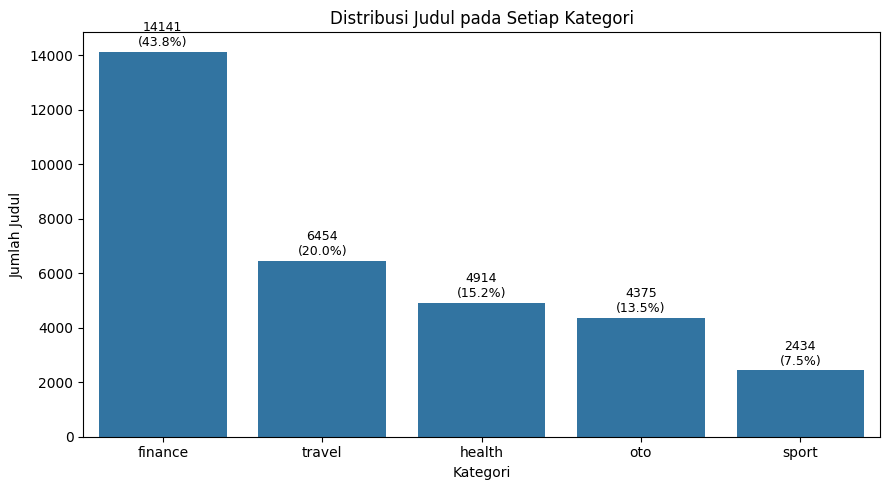

In [6]:
# ==================== 
# Visualisasi distribusi kategori
# ====================

# Menghitung jumlah judul pada setiap kategori dan mengurutkannya secara menurun
category_counts = df['category'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, order=category_counts.index)

# Tambahkan anotasi pada setiap batang grafik yang menampilkan jumlah data dan persentase dari total keseluruhan
total = category_counts.sum()
for i, value in enumerate(category_counts.values):
    pct = value / total * 100
    ax.text(i, value + 200, f"{value}\n({pct:.1f}%)", ha='center', fontsize=9)

plt.title('Distribusi Judul pada Setiap Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Judul')
plt.tight_layout()
plt.show()

**✦ Insight dari Visualisasi Distribusi Kategori diatas adalah sebagai berikut:**

- Total data final ada 32.318 judul, tersebar ke lima kategori dengan proporsi finance 43.8% (14.141), travel 20.0% (6.454), health 15.2% (4.914), oto 13.5% (4.375), dan sport 7.5% (2.434). Angka ini konsisten dengan hasil validasi di tahap Data Loading, jadi tidak ada penyimpangan.

- Rasio antara kategori terbesar dan terkecil sekitar 5.8 kali lipat (finance dibanding sport). Ini bukan sekadar catatan statistik, tapi implikasi langsung ke proses training nanti. Kalau tidak ditangani, model akan cenderung bias memprediksi finance karena model punya insentif statistik untuk begitu, apalagi dengan metrik accuracy biasa yang bisa menipu di kondisi imbalance seperti ini. Karena itu di tahap Feature Engineering nanti, strategi seperti class_weight atau resampling perlu dipertimbangkan, bukan diabaikan.

#### 4.2 Distribusi Panjang Judul per Kategori

Statistik Jumlah Kata pada Setiap Kategori:
            count      mean       std  min  25%   50%   75%   max
category                                                         
finance   14141.0  8.494873  1.627184  3.0  7.0   9.0  10.0  15.0
health     4914.0  9.735450  1.566498  4.0  9.0  10.0  11.0  15.0
oto        4375.0  8.792686  1.967905  3.0  7.0   9.0  10.0  16.0
sport      2434.0  8.158176  1.730520  2.0  7.0   8.0   9.0  13.0
travel     6454.0  8.131081  1.719845  2.0  7.0   8.0   9.0  16.0

Statistik Jumlah Karakter pada Setiap Kategori:
            count       mean        std   min   25%   50%   75%   max
category                                                             
finance   14141.0  54.496005   9.494698  18.0  48.0  56.0  62.0  85.0
health     4914.0  63.876068   8.963089  25.0  59.0  66.0  70.0  87.0
oto        4375.0  57.178743  12.026455  16.0  49.0  58.0  65.0  95.0
sport      2434.0  54.800329  11.004744  17.0  47.0  56.0  62.0  91.0
travel     6454.0  53.273

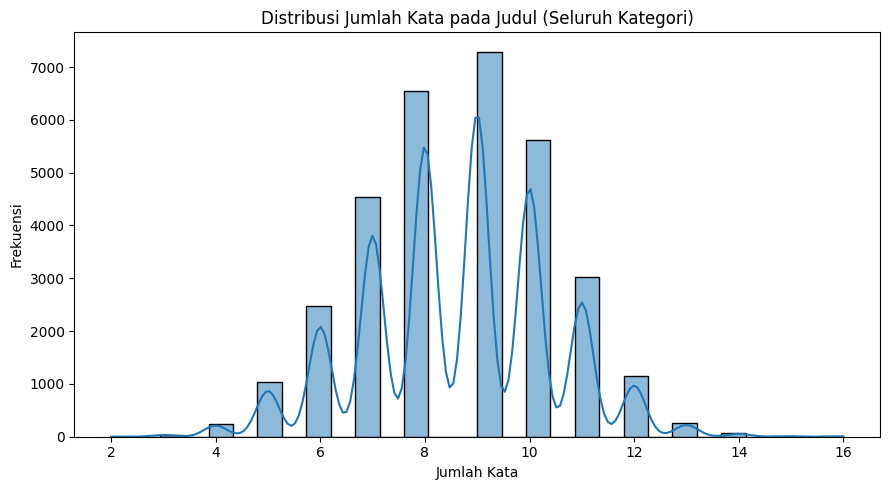

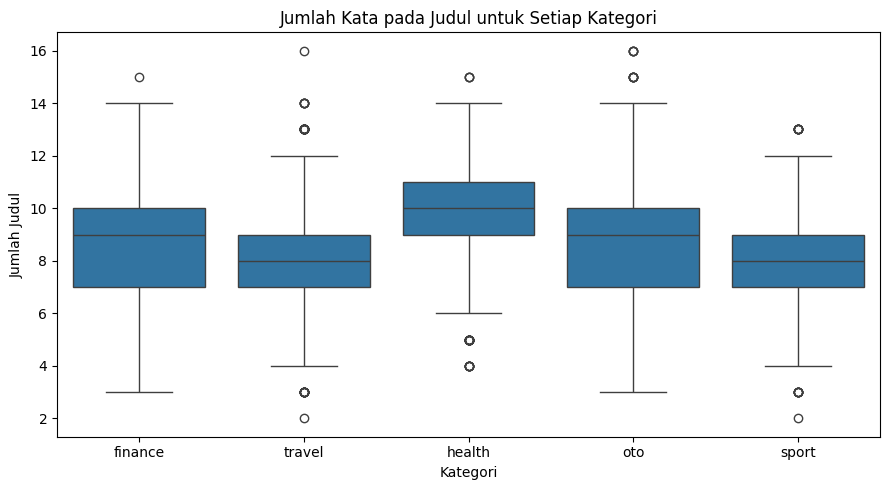

Skewness: -0.06087130708874271
Kurtosis: -0.05819427777695507


In [7]:
# ==================== 
# Distribusi panjang judul per kategori
# ====================

# Membuat fitur baru dari panjang judul
df['title_word_count'] = df['title'].apply(lambda x: len(x.split()))
df['title_char_count'] = df['title'].apply(len)

# Statistik deskriptif untuk setiap kategori sebagai referensi dalam menentukan nilai max_length pada tahap selanjutnya
desc_word = df.groupby('category')['title_word_count'].describe()
desc_char = df.groupby('category')['title_char_count'].describe()
print("Statistik Jumlah Kata pada Setiap Kategori:")
print(desc_word)
print("\nStatistik Jumlah Karakter pada Setiap Kategori:")
print(desc_char)

# Histogram distribusi jumlah kata pada seluruh data
plt.figure(figsize=(9, 5))
sns.histplot(df['title_word_count'], bins=30, kde=True)
plt.title('Distribusi Jumlah Kata pada Judul (Seluruh Kategori)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Boxplot jumlah kata pada setiap kategori untuk membandingkan penyebaran data dan mengidentifikasi pencilan (outlier)
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='title_word_count', order=category_counts.index)
plt.title('Jumlah Kata pada Judul untuk Setiap Kategori')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Judul')
plt.tight_layout()
plt.show()

# Skewness dan kurtosis jumlah kata sebagai ukuran untuk menggambarkan bentuk distribusi data
print("Skewness:", df['title_word_count'].skew())
print("Kurtosis:", df['title_word_count'].kurt())

**✦ Insight dari Panjang Judul per Kategori**

- Dari sisi jumlah kata, health punya rata-rata paling panjang (9.74 kata, std 1.57), jelas berbeda dari empat kategori lain yang berkisar di 8.1 sampai 8.8 kata. Pola yang sama muncul di jumlah karakter, health rata-rata 63.9 karakter sementara kategori lain di kisaran 53 sampai 57 karakter. Ini masuk akal kalau dipikir dari sisi konten, judul berita kesehatan selama periode ini banyak memuat update angka kasus, status pasien, dan istilah medis yang butuh kata lebih banyak untuk dijelaskan di judul, dibanding misalnya judul otomotif yang bisa singkat seperti nama produk dan harga.

- Skewness keseluruhan -0.06 dan kurtosis -0.06, dua-duanya mendekati nol. Artinya distribusi jumlah kata ini praktis simetris dan mendekati normal, tidak ada ekor panjang yang mengkhawatirkan. Ini kabar baik untuk keputusan max_length di tokenizer nanti, karena tidak perlu antisipasi outlier ekstrem yang memaksa padding jadi sangat panjang.

- Visualisasi dari Boxplot menunjukkan tiap kategori punya outlier di kedua ujung, judul terpendek 2 kata sampai judul terpanjang 16 kata, tapi jumlahnya sedikit dan sudah konsisten dengan rentang IQR yang wajar.

- Visualisasi dari barchart menunjukan pola bergerigi yang naik turun di grafik, itu bukan pola distribusi asli dimana itu artefak dari jumlah bins yang dipakai (30 bins) terhadap data yang sebenarnya cuma punya nilai integer terbatas dari 2 sampai 16 kata. Beberapa bin jadi kosong sehingga terlihat seperti pola bergelombang.

#### 4.3 Word Frequency per Kategori

In [8]:
# ==================== 
# Word frequency per kategori (setelah cleaning dan stopword removal)
# ====================

# Membuat penghapus stopword bahasa Indonesia
stopword_factory = StopWordRemoverFactory()
stopwords_id = set(stopword_factory.get_stop_words())

def clean_text(text):
    # Mengubah seluruh teks menjadi huruf kecil
    text = text.lower()
    # Menghapus tanda baca dan karakter selain huruf alfabet
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_tokens(text):
   # Membersihkan teks, kemudian memecahnya menjadi token dan menghapus stopword
    cleaned = clean_text(text)
    tokens = [word for word in cleaned.split() if word not in stopwords_id and len(word) > 2]
    return tokens

# Menerapkan proses pembersihan untuk membuat kolom token
df['title_tokens'] = df['title'].apply(get_tokens)

# Menampilkan 15 kata yang paling sering muncul pada setiap kategori
for cat in category_counts.index:
    tokens_flat = [token for tokens in df.loc[df['category'] == cat, 'title_tokens'] for token in tokens]
    top_words = Counter(tokens_flat).most_common(15)
    print(f"\nKata-kata yang Paling Sering Muncul pada Kategori: {cat}")
    for word, freq in top_words:
        print(f"{word}: {freq}")


Kata-kata yang Paling Sering Muncul pada Kategori: finance
corona: 2470
harga: 701
jokowi: 642
tak: 623
jadi: 582
mau: 562
ekonomi: 536
kerja: 535
naik: 510
hingga: 497
soal: 495
erick: 453
gara: 446
bumn: 443
pemerintah: 435

Kata-kata yang Paling Sering Muncul pada Kategori: travel
corona: 1023
wisata: 525
foto: 333
dunia: 299
turis: 284
indonesia: 269
potret: 264
tempat: 247
pesawat: 240
tak: 238
kota: 229
virus: 224
jadi: 215
bali: 211
pantai: 201

Kata-kata yang Paling Sering Muncul pada Kategori: health
corona: 2590
virus: 1040
pasien: 471
indonesia: 427
meninggal: 413
kasus: 364
positif: 360
tak: 329
sembuh: 309
covid: 263
dokter: 210
cara: 207
jadi: 196
baru: 187
masker: 185

Kata-kata yang Paling Sering Muncul pada Kategori: oto
mobil: 1205
corona: 576
motor: 432
indonesia: 256
honda: 255
jadi: 221
listrik: 215
tak: 195
jakarta: 189
baru: 186
toyota: 176
kendaraan: 159
banjir: 155
juta: 152
pakai: 149

Kata-kata yang Paling Sering Muncul pada Kategori: sport
corona: 228
indon

**✦ Insight dari Word Frequency per Kategori**

- Temuan paling mencolok, kata "corona" jadi kata teratas di hampir semua kategori: finance, travel, health, dan sport, kecuali oto di mana "mobil" sedikit lebih sering muncul dan corona ada di posisi kedua. Ini masuk akal mengingat rentang data Januari sampai Juni 2020 yang bertepatan dengan awal pandemi, jadi seluruh siklus berita media saat itu memang terpengaruh topik ini, apapun kategorinya.

- Yang menariknya, di luar kata "corona" yang bersifat lintas kategori, tiap kategori tetap menunjukkan kata khas masing-masing yang jelas berbeda. Finance didominasi nama tokoh dan istilah ekonomi seperti jokowi, ekonomi, erick, bumn. Travel condong ke wisata, turis, pantai, bali. Health penuh istilah medis seperti pasien, meninggal, kasus, sembuh, dokter. Oto jelas dengan mobil, motor, honda, toyota. Sport dengan motogp, olimpiade, rossi, marquez, gol.

- Ini membuktikan hipotesis vocabulary separability yang menjadi alasan milih lima kategori ini di awal. Meski ada satu kata dominan yang tumpang tindih karena faktor waktu (corona), begitu kata itu disingkirkan dari perhatian, sisa vocabulary tiap kategori tetap punya identitas yang kuat dan mudah dibedakan.

#### 4.4 WorldCloud per Kategori

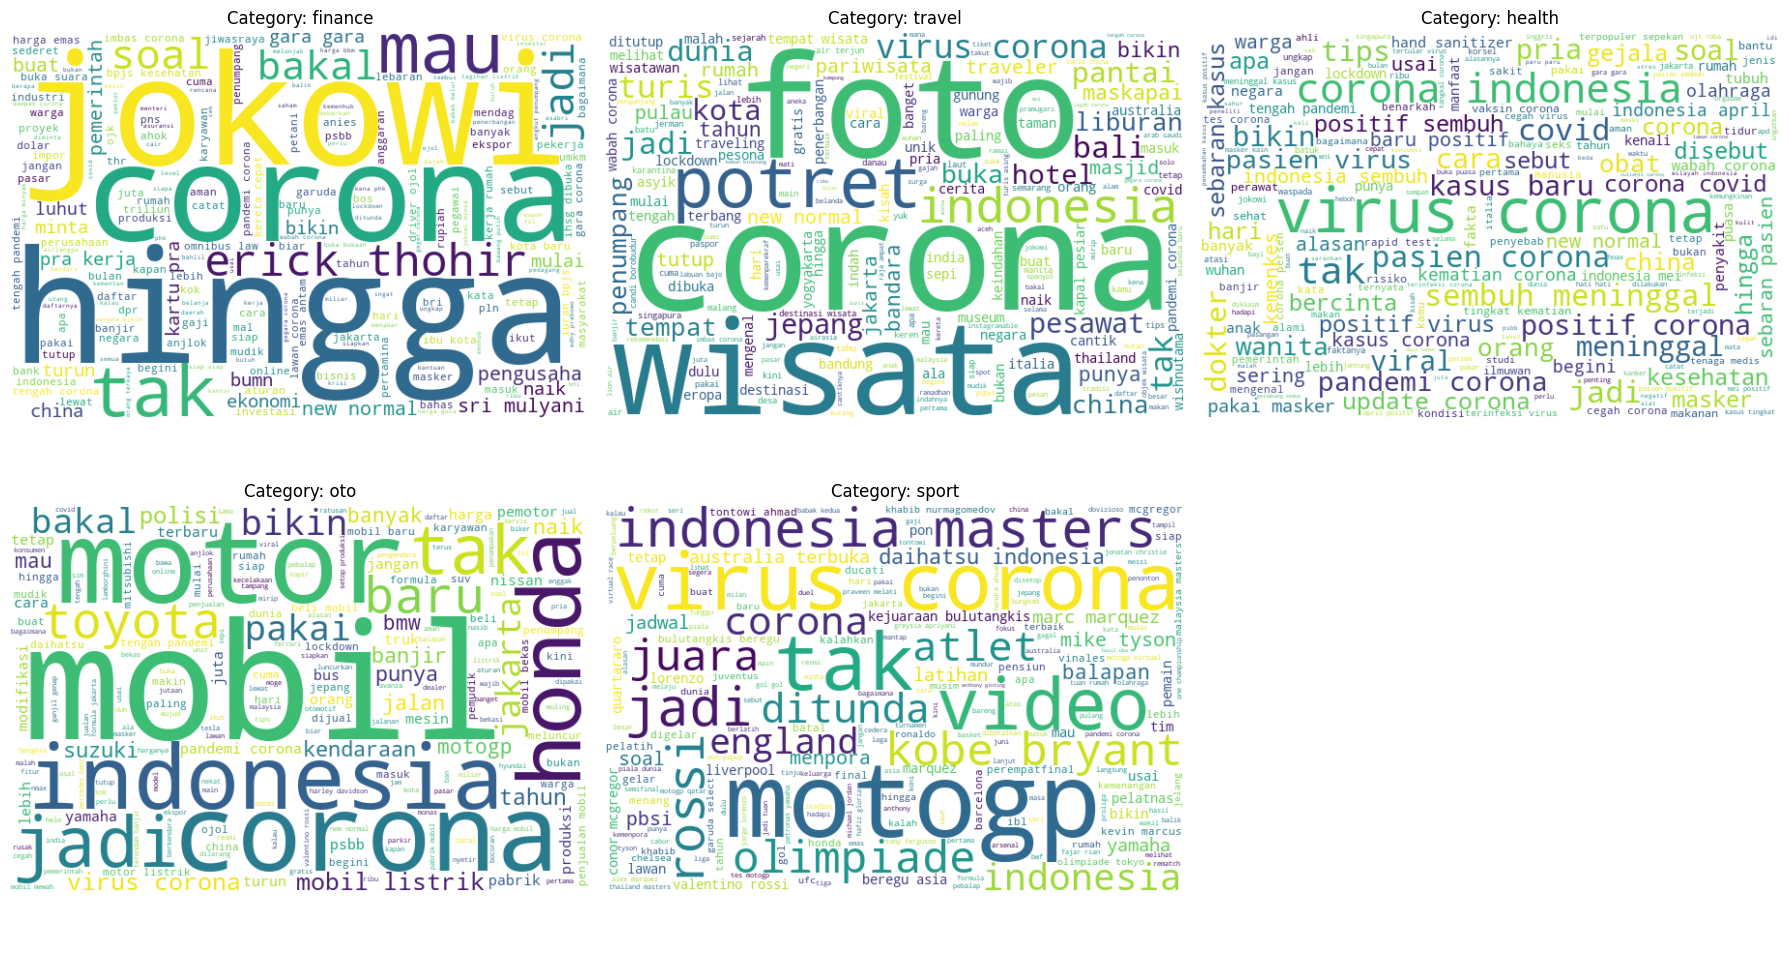

In [9]:
# ==================== 
# WordCloud per kategori
# ====================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(category_counts.index):
    tokens_flat = [token for tokens in df.loc[df['category'] == cat, 'title_tokens'] for token in tokens]
    text_combined = ' '.join(tokens_flat)
    wc = WordCloud(width=600, height=400, background_color='white', colormap='viridis', random_state=88).generate(text_combined)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Category: {cat}")
    axes[i].axis('off')

# Sembunyikan subplot keenam yang tidak digunakan karena hanya terdapat 5 kategori
axes[5].axis('off')

plt.tight_layout()
plt.show()

**✦ Insight dari WordCloud per Kategori**

- Secara visual, wordcloud ini menguatkan temuan poin 3. Corona atau virus corona tampil besar di finance, travel, health, dan oto. Corona tetap salah satu kata dominan di sport, tapi persaingannya dengan istilah olahraga (motogp, masters, olimpiade) lebih ketat dibanding kategori lain yang praktis dikuasai penuh oleh corona. Ini masuk akal karena meski banyak berita sport periode itu membahas dampak corona (jadwal pertandingan ditunda/dibatalkan), nama kompetisi dan atlet tetap disebut eksplisit di judul sebagai konteks utama, sehingga istilah olahraga tidak sepenuhnya kalah frekuensi dari kata "corona" itu sendiri.

#### 4.5 N-gram analysis (bigram dan trigram) per Kategori

In [10]:
# ==================== 
# N-gram analysis (bigram dan trigram) per kategori
# ====================

def get_top_ngrams(text_series, ngram_range, top_n=10):
    # Melatih (fit) CountVectorizer pada kumpulan teks yang diberikan dengan rentang n-gram tertentu
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=list(stopwords_id))
    ngram_matrix = vectorizer.fit_transform(text_series)
    ngram_counts = ngram_matrix.sum(axis=0)
    ngram_freq = [(word, ngram_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    ngram_freq = sorted(ngram_freq, key=lambda x: x[1], reverse=True)
    return ngram_freq[:top_n]

# Menyiapkan teks yang telah dibersihkan, sementara penghapusan stopword akan dilakukan oleh vectorizer
df['title_cleaned'] = df['title'].apply(clean_text)

for cat in category_counts.index:
    subset = df.loc[df['category'] == cat, 'title_cleaned']
    print(f"\nTop bigrams in category: {cat}")
    for phrase, freq in get_top_ngrams(subset, ngram_range=(2, 2)):
        print(f"{phrase}: {freq}")

    print(f"\nTop trigrams in category: {cat}")
    for phrase, freq in get_top_ngrams(subset, ngram_range=(3, 3)):
        print(f"{phrase}: {freq}")


Top bigrams in category: finance
erick thohir: 404
sri mulyani: 318
new normal: 311
pra kerja: 232
gara gara: 223
dolar as: 212
kartu pra: 194
ekonomi ri: 187
bpjs kesehatan: 176
virus corona: 162

Top trigrams in category: finance
kartu pra kerja: 194
gara gara corona: 139
ibu kota baru: 119
iuran bpjs kesehatan: 87
harga emas antam: 67
tengah pandemi corona: 45
proyek kereta cepat: 41
buka suara soal: 37
as tembus rp: 31
dolar as tembus: 31

Top bigrams in category: travel
virus corona: 216
new normal: 101
tempat wisata: 91
pandemi corona: 67
wabah corona: 54
kapal pesiar: 48
destinasi wisata: 47
air terjun: 40
candi borobudur: 38
imbas corona: 35

Top trigrams in category: travel
tengah pandemi corona: 16
efek corona wisata: 14
imbas virus corona: 14
corona wisata ri: 12
era new normal: 12
wabah virus corona: 11
wisata ri per: 11
bandara soekarno hatta: 11
batu secret zoo: 10
tengah wabah corona: 10

Top bigrams in category: health
virus corona: 985
corona indonesia: 299
pasien cor

**✦ Insight dari N-gram Analysis (Bigram dan Trigram)**

- Ini bagian yang paling menjawab kekhawatiran soal dominasi kata "corona" di poin 3. Begitu dilihat dalam bentuk frasa dua atau tiga kata, karakter tiap kategori jadi jauh lebih tajam dan spesifik.

- Finance menonjolkan nama pejabat dan kebijakan seperti "erick thohir" (404), "sri mulyani" (318), "kartu pra kerja" (194), "bpjs kesehatan" (176). Travel mengarah ke destinasi seperti "tempat wisata", "kapal pesiar", "candi borobudur". Health sangat spesifik ke pelaporan kasus seperti "update corona indonesia", "positif sembuh meninggal", "sebaran kasus baru". Oto condong ke spesifikasi dan harga seperti "mobil listrik", "rp jutaan", "motor listrik". Sport menonjolkan nama kompetisi dan atlet seperti "indonesia masters", "kobe bryant", "all england", "marc marquez".

> Meskipun kata tunggal "corona" muncul di semua kategori, begitu dilihat dalam konteks frasa, tiap kategori punya cara bicara sendiri soal corona itu. Health membahas soal kasus dan pasien, oto membahas dampak ke harga dan penjualan, travel membahas dampak ke destinasi wisata. Artinya konteks kata jauh lebih informatif dibanding kata itu sendiri, ini alasan kuat kenapa nanti model ANN yang dipakai sebaiknya bisa menangkap urutan kata (misalnya lewat embedding dan layer yang mempertimbangkan sequence), bukan cuma bag-of-words biasa yang mengabaikan urutan.

#### 4.6 Tren volume Berita per Waktu

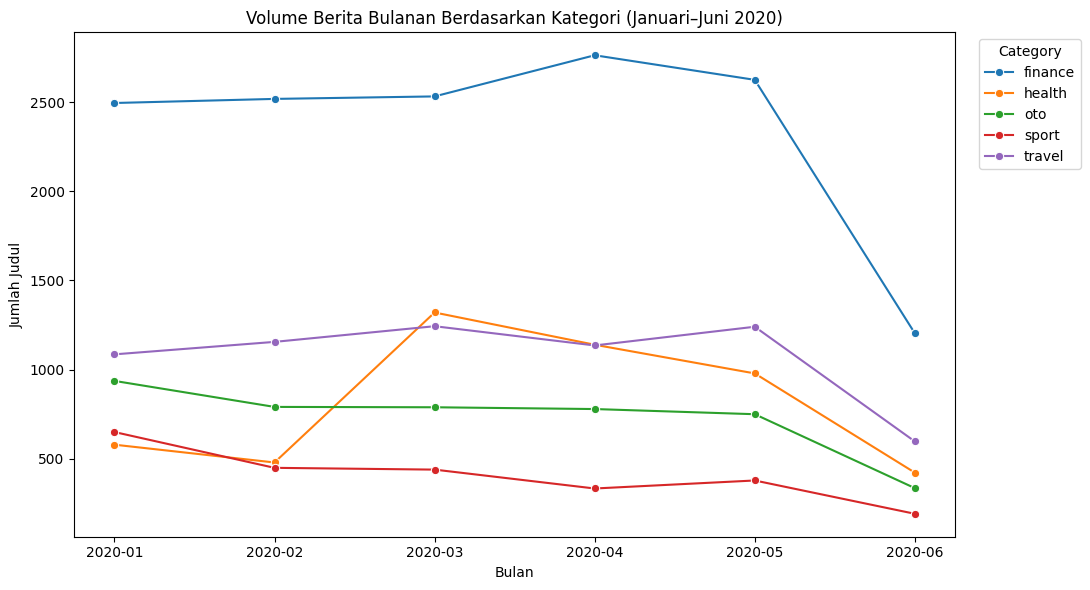

In [11]:
# ==================== 
# Tren volume berita per waktu (per bulan per kategori)
# ====================

# Mengekstrak periode tahun dan bulan dari kolom tanggal
df['year_month'] = df['date'].dt.to_period('M').astype(str)

# Menghitung jumlah judul setiap bulan berdasarkan kategori
monthly_trend = df.groupby(['year_month', 'category']).size().reset_index(name='count')

plt.figure(figsize=(11, 6))
sns.lineplot(data=monthly_trend, x='year_month', y='count', hue='category', marker='o')
plt.title('Volume Berita Bulanan Berdasarkan Kategori (Januari–Juni 2020)')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Judul')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**✦ Insight dari Tren Volume Berita per Waktu**

- Dari Januari sampai Mei, pola tiap kategori relatif stabil di levelnya masing-masing, finance konsisten di kisaran 2500 sampai 2700-an judul per bulan, travel di kisaran 1100 sampai 1200-an, oto dan sport cenderung datar di angka lebih rendah.

- Ada satu titik yang menonjol, health melonjak tajam dari sekitar 400-an judul di Februari jadi 1300-an judul di Maret. Ini bertepatan dengan pengumuman kasus positif corona pertama di Indonesia pada awal Maret 2020, jadi lonjakan ini bukan kebetulan, ini refleksi langsung dari momen tersebut di volume pemberitaan.

- Semua kategori menunjukkan penurunan tajam di Juni, tapi ini tidak boleh dibaca sebagai tren penurunan minat berita. Rentang data pada dataset ini hanya sampai 13 Juni 2020, jadi bulan Juni ini datanya hanya sebagian, sekitar 13 hari dibanding bulan-bulan lain yang penuh.

- Terlihat volume berita travel tidak anjlok drastis meski dunia nyatanya lagi lockdown. Yang terjadi justru volume beritanya tetap jalan di level yang mirip dengan sebelum pandemi. Ini masuk akal kalau dipikir ulang, media tetap menulis soal travel selama pandemi, cuma temanya berubah jadi soal dampak corona ke sektor pariwisata, destinasi yang tutup, atau prediksi kapan wisata bisa jalan lagi, bukan berarti liputan soal traveling itu sendiri berhenti.


#### 4.7 Pengecheckan Anomali Judul

In [12]:
# ==================== 
# Cek anomali judul (terlalu pendek atau karakter tidak wajar)
# ====================

# Menandai judul yang pendek dimana kemungkinan tidak lengkap atau kurang informatif
short_titles = df[df['title_word_count'] <= 2]
print(f"Number of titles with 2 words or less: {len(short_titles)}")
print(short_titles[['title', 'category']].head(10))

# Menandai judul yang mengandung karakter tidak umum di luar tanda baca yang lazim.
def has_unusual_chars(text):
    # Memeriksa apakah judul mengandung karakter selain huruf, angka, spasi, dan tanda baca yang umum digunakan
    return bool(re.search(r'[^a-zA-Z0-9\s.,\-\'\"()%?!:]', text))

df['has_unusual_chars'] = df['title'].apply(has_unusual_chars)
unusual_titles = df[df['has_unusual_chars']]
print(f"\nJumlah Judul yang Mengandung Karakter Tidak Lazim: {len(unusual_titles)}")
pd.set_option('display.max_colwidth', None)
print(unusual_titles[['title', 'category']].head(15))

Number of titles with 2 words or less: 2
                      title category
24941  Bundesliga Comeback!    sport
30054      Kasihan Koala...   travel

Jumlah Judul yang Mengandung Karakter Tidak Lazim: 879
                                                                      title  \
193    BPH Migas Gandeng UI Atasi Dampak Corona & Tingkatkan Distribusi BBM   
229                 IHSG Anjlok, Rupiah Kembali Terperosok ke Rp 14.253/US$   
254                Enak Banget! Kerja di Bank Bisa Digaji Rp 416 Juta/Bulan   
290    Ari Askhara Cs Lengser, Apa Kabar Kasus Harley & Brompton di Garuda?   
321              Mulai Langka, Beli Masker di New York Dibatasi 1 Pcs/Orang   
330          Usai Mati Suri 43 Tahun, Segini Tarif KeretaÂ Padang-Pulau Air   
342          Operasi Pasar Nggak Ngaruh, Harga Masker Tembus Rp 500.000/Box   
349                    Dahsyat! Harga Jahe Merah Sudah Tembus Rp 100.000/Kg   
357                    Mantul! Harga Emas Diprediksi Tembus Rp 900.000/Gram   
37

**✦ Insight dari Anomali Judul**

- Judul yang sangat pendek (dua kata atau kurang) cuma ada 2 dari 32.318 data, yaitu "Bundesliga Comeback!" dan "Kasihan Koala...". Jumlahnya kecil sekali sehingga tidak perlu perlakuan khusus.

- Terdapat temuan 879 judul anomali dimana dari 879 sisa temuan ini, setelah ditelusuri satu per satu, ternyata terbagi jadi dua kelompok dengan sifat yang berbeda:
    * Kelompok pertama adalah tanda baca umum yang belum masuk whitelist, seperti ampersand pada "Harley & Brompton", "THR & Gaji", tanda seru pada "Enak Banget!" dan "Dahsyat!", garis miring pada satuan seperti "Rp 416 Juta/Bulan" dan "Rp 500.000/Box", tanda dolar pada "Rp 14.253/US$", tanda pagar pada "#Indonesia_LockdownPlease", dan tanda tanya di judul yang memang berbentuk pertanyaan seperti "Kapan Harus Jual?". Semua ini gaya penulisan headline yang wajar, bahkan cenderung khas media online yang suka pakai tanda seru untuk clickbait ringan (Enak Banget!, Mantul!, Dahsyat!). Tidak ada yang perlu dianggap masalah di sini.
    * Kelompok kedua, terdapat judul yang mengandung karakter mojibake "Â" dimana ini bukan tanda baca gaya penulisan. Perlu dilakukan pengecheckan lebih dalam terkait karakter mojibake "Â" ini untuk menentukan perlu ditangani eksplisit di fungsi clean_text atau tidak.

In [13]:
# Pengecheckan jumlah karakter mojibake 'Â' pada judul
jumlah_mojibake = df['title'].str.contains('Â', regex=False).sum()
print(f"\nJumlah judul yang mengandung karakter mojibake 'Â': {jumlah_mojibake}")
print(df.loc[df['title'].str.contains('Â', regex=False), 'title'].head(10).tolist())


Jumlah judul yang mengandung karakter mojibake 'Â': 102
['Usai Mati Suri 43 Tahun, Segini Tarif KeretaÂ\xa0Padang-Pulau Air', "Bisnis Event Organizer Ikut 'Demam' Gara-gara CoronaÂ", 'Rumah Rp 788 Juta All-In Dekat Bandara SoettaÂ', 'Pintu Keluar Tol Rawa Bokor DitutupÂ\xa0Mulai 1 April', '14.500Â\xa0Perusahaan Dapat Izin Operasi Selama PSBB, Kok Bisa?', 'Ajak KUMKM, Menkop TetenÂ\xa0Gaungkan GerakanÂ\xa0#MaskerKainUntukSemua', 'Tips Kelola Keuangan UMKMÂ\xa0Saat Darurat Corona', 'Bio Farma Bakal ProduksiÂ\xa0100.000Â\xa0Alat Tes Corona', 'Anies Singgung MRT-TransJakartaÂ\xa0Layang Tak Tersambung, Sindir Ahok?', 'Harga Cabai Tembus RpÂ\xa0100.000/Kg, Mentan: Saya Cek']


**✦ Insight Pengecheckan Karakter Mojibake 'Â'**

- Ditemukan sebanyak 102 judul, mengandung karakter mojibake "Â" yang selalu diikuti karakter non-breaking space (\xa0), misalnya pada "KeretaÂ\xa0Padang-Pulau Air" atau "14.500Â\xa0Perusahaan". Pola ini konsisten muncul di tempat yang seharusnya cuma spasi biasa, jadi kemungkinan besar ini artefak dari proses scraping, saat karakter non-breaking space di HTML asli (biasanya dari entity semacam &nbsp;) tidak ter-decode dengan benar dan berubah jadi dua karakter yang salah baca.

- Temuan ini tidak berdampak ke proses modeling. Sudah diverifikasi langsung, fungsi `clean_text` yang dipakai untuk tahap Feature Engineering nanti otomatis membersihkan karakter "Â" ini karena bukan huruf a sampai z, sementara \xa0 di sebelahnya tetap terbaca sebagai pemisah kata oleh Python. Jadi kata seperti "KeretaÂ\xa0Padang" tetap terpecah benar jadi token "kereta" dan "padang" terpisah, bukan jadi satu token rusak yang mengurangi kualitas vocabulary.

>> **Kesimpulannya**, dari 879 judul yang awalnya diduga anomali, tidak ada satupun yang butuh penanganan khusus tambahan di luar pipeline cleaning yang sudah dirancang. Dua kelompok temuan ini murni catatan dokumentasi, bukti bahwa proses pengecekan data dilakukan dengan teliti, bukan langkah yang mengubah strategi cleaning.

#### 4.8 Pengechcekan Anomali Teks dari Emoji, Singkatan, dan Typo

In [14]:
# ==================== 
# Cek anomali teks dari emoji, singkatan, dan typo
# ====================

# Cek keberadaan emoji di judul menggunakan rentang unicode emoji
pola_emoji = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticon
    "\U0001F300-\U0001F5FF"  # simbol dan pictograph
    "\U0001F680-\U0001F6FF"  # transportasi dan simbol
    "\U0001F1E0-\U0001F1FF"  # bendera
    "\U00002700-\U000027BF"  # dingbats
    "\U0001F900-\U0001F9FF"  # simbol tambahan
    "]+", flags=re.UNICODE
)

judul_dengan_emoji = df[df['title'].apply(lambda x: bool(pola_emoji.search(x)))]
print(f"Jumlah judul yang mengandung emoji: {len(judul_dengan_emoji)}")
if len(judul_dengan_emoji) > 0:
    print(judul_dengan_emoji[['title', 'category']].head(10))

# Cek keberadaan singkatan gaya chat atau bahasa gaul yang tidak lazim di judul berita formal
# Kita gunakan salah satu kamus slang bahasa Indonesia terpopuler di GitHub
url_kamus_slang = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
try:
    # Membaca file CSV kamus slang langsung dari internet
    df_kamus = pd.read_csv(url_kamus_slang)
    
    # Mengubah dataframe kamus menjadi Python Dictionary agar proses pencarian secepat kilat
    # Kolom 'formal' adalah kata baku, kolom 'slang' adalah kata gaulnya
    kamus_otomatis = dict(zip(df_kamus['slang'], df_kamus['formal']))
    print(f"Berhasil memuat {len(kamus_otomatis)} kata gaul dari GitHub!")
except Exception as e:
    print("Gagal memuat dari internet, menggunakan kamus cadangan.")
    kamus_otomatis = [
        'gk', 'ga', 'nggak', 'ngga', 'gak', 'yg', 'dgn', 'utk', 'krn',
        'jd', 'jgn', 'kalo', 'gimana', 'gmn', 'sm', 'jg', 'aja', 'udh', 'blm'
    ]

# Method untuk pengecheckan text singkatan
def cek_singkatan(text, daftar_kata):
    # Pecah judul jadi kata per kata dalam bentuk huruf kecil semua
    kata_kata = text.lower().split()
    ditemukan = [kata for kata in kata_kata if kata in daftar_kata]
    return ditemukan

df['singkatan_ditemukan'] = df['title'].apply(lambda x: cek_singkatan(x, kamus_otomatis))
total_singkatan = Counter([kata for daftar in df['singkatan_ditemukan'] for kata in daftar])

print("\nFrekuensi singkatan gaya chat yang ditemukan di judul:")
if len(total_singkatan) > 0:
    for kata, freq in total_singkatan.most_common():
        print(f"{kata}: {freq}")
else:
    print("Tidak ditemukan singkatan gaya chat pada judul berita.")

# Cek indikasi typo lewat token yang sangat jarang muncul, hanya satu kali di seluruh dataset
semua_kata = ' '.join(df['title'].str.lower()).split()
frekuensi_kata = Counter(semua_kata)
kata_langka = [kata for kata, freq in frekuensi_kata.items() if freq == 1 and kata.isalpha() and len(kata) > 3]

print(f"\nJumlah kata unik yang hanya muncul satu kali di seluruh dataset: {len(kata_langka)}")
print("Contoh kata yang jarang muncul, kandidat typo atau nama entitas spesifik:")
print(kata_langka[:20])

# Ambil sample acak untuk spot check manual terhadap typo
print("\nSample acak 15 judul untuk pengecekan manual:")
sample_manual = df['title'].sample(15, random_state=88)
for judul in sample_manual:
    print(f"- {judul}")

Jumlah judul yang mengandung emoji: 0
Berhasil memuat 4331 kata gaul dari GitHub!

Frekuensi singkatan gaya chat yang ditemukan di judul:
minta: 483
nggak: 322
m: 178
si: 78
kaya: 59
spt: 47
pgn: 40
ka: 39
in: 34
nonton: 31
dr: 31
pede: 27
km: 27
bca: 24
ngaku: 24
haru: 22
ma: 21
gimana: 18
nambah: 16
aja: 15
c: 14
ginting: 14
ap: 13
ngobrol: 12
sma: 12
la: 11
beneran: 11
de: 11
may: 9
ortu: 9
fans: 8
kw: 8
mg: 8
gak: 7
cobain: 7
ngomong: 6
mw: 6
kk: 6
naksir: 6
rb: 6
pd: 6
naek: 6
abg: 6
x: 6
abs: 6
nempel: 5
abis: 5
z: 5
ade: 5
s: 5
nangis: 5
mk: 4
bkn: 4
to: 4
sby: 4
bird: 4
sam: 4
sk: 4
nyatakan: 4
ngapain: 4
le: 4
pgi: 4
kl: 3
ngajar: 3
it: 3
pala: 3
d: 3
tai: 3
ps: 3
sp: 3
murmer: 3
indo: 3
ngambek: 3
ngakak: 3
gw: 2
gt: 2
co: 2
ko: 2
udah: 2
ngadu: 2
nunggu: 2
khan: 2
mikirin: 2
narik: 2
nyusul: 2
ngomongin: 2
gini: 2
cm: 2
make: 2
jk: 2
ga: 2
pass: 2
cantika: 2
so: 2
nyebelin: 2
nyolong: 2
kuy: 2
gitu: 2
mo: 2
tuk: 2
nha: 2
sewain: 1
nuduh: 1
suko: 1
pen: 1
lha: 1
ngerti: 1
kek

**✦ Insight dari Emoji, Bahasa Gaul, dan Typo**

- Tidak ditemukan emoji sama sekali di seluruh judul (0 dari 32.318). Ini sesuai dugaan awal, media berita formal seperti detik.com memang tidak memakai emoji di headline.

- Untuk pengecekan bahasa gaul, dictionary eksternal dari GitHub yang dipakai (4331 kata) menghasilkan kata yang terasa seperti bahasa percakapan hanya sebagian kecil saja, seperti "minta" (483), "nggak" (322), "gimana" (18), "aja" (15), "gak" (7), dan "ga" (2) dengan frekuensi yang jauh lebih kecil dibanding total 32.318 judul. Jadi bahasa gaul bukan masalah besar di dataset ini. **Output dari pengecheckan kamus slank ini bisa berubah ketika dilakukan running pada aplikasi mengingat data sampling yang diambil langsung dari URL github (internet).**

- Untuk indikasi typo, ada 5668 kata unik yang cuma muncul sekali di seluruh dataset. Tapi setelah dicek contohnya, seperti "pltm", "bunaken", "orba", "superholding", "dipolitisasi", kata-kata ini kebanyakan singkatan resmi, nama tempat, istilah sejarah, atau kosakata formal yang memang jarang dipakai, bukan typo. Sample manual 15 judul juga tidak menunjukkan typo yang jelas, semuanya ditulis dengan kaidah jurnalistik yang rapi.

>> **Kesimpulannya**, dataset ini relatif bersih dari sisi penulisan. Tidak ada emoji, bahasa gaul yang benar-benar signifikan jumlahnya kecil, dan tidak ditemukan indikasi typo yang berarti dari sample manual. Karena itu fungsi cleaning untuk tahap Feature Engineering nanti bisa tetap sederhana, cukup lowercase, hapus tanda baca, dan hapus stopword, tanpa perlu membangun sistem koreksi typo atau normalisasi bahasa gaul yang rumit.

---

### **5. Feature Engineering**
Berdasarkan hasil EDA pada tahap sebelumnya, berikut adalah rangkaian proses 
Feature Engineering yang akan dilakukan sebelum melatih model, yaitu:
1. Text Cleaning, terapkan fungsi clean_text yang sudah kita rancang waktu EDA (lowercase, hapus non huruf, hapus stopword pakai Sastrawi)
2. Train-Validation-Test Split, dilakukan sebelum tokenization, ini penting supaya tidak ada data leakage
3. Label Encoding, ubah 5 kategori jadi angka lalu one-hot
4. Class Imbalance Handling, saya akan pakai class_weight, alasan lengkap ada di code
5. Text Vectorization pakai Tokenizer, fit hanya di data train, vocab_size ditentukan dari analisis coverage kata
6. Padding Sequences, max_length ditentukan dari distribusi panjang judul hasil cleaning, bukan dari raw title

#### 5.1 Text Cleaning

In [15]:
# menerapkan fungsi clean_text yang sudah divalidasi di tahap EDA
# lowercase, hapus karakter selain huruf, hapus spasi berlebih, hapus stopword bahasa indonesia

factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stopword_remover.remove(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['title_clean'] = df['title'].apply(clean_text)

# cek apakah ada judul yang jadi kosong setelah cleaning
print('Jumlah judul kosong setelah cleaning:', (df['title_clean'].str.len() == 0).sum())

Jumlah judul kosong setelah cleaning: 0


**✦ Insight dari Analisis Text Cleaning**

Setelah fungsi `clean_text` diterapkan ke seluruh 32.318 judul, tidak ada satu pun judul yang berubah jadi string kosong. Artinya tidak ada judul yang isinya cuma stopword atau karakter non huruf semata, jadi tidak perlu ada baris yang di-drop di tahap ini. Cleaning bisa dianggap aman dipakai langsung ke proses berikutnya tanpa kehilangan data.

#### 5.2 Train-Validation-Test Split

In [16]:
# split 70 persen train, sisa 30 persen dibagi rata jadi 15 persen val dan 15 persen test
# stratify pakai kolom category supaya proporsi tiap kelas terjaga di semua split
# mengingat class imbalance 5.8x, stratify wajib dipakai, kalau tidak sport bisa kurang terwakili di test set

X_train, X_temp, y_train, y_temp = train_test_split(
    df['title_clean'], df['category'],
    test_size=0.30, random_state=88, stratify=df['category']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50, random_state=88, stratify=y_temp
)

print('Jumlah data train:', len(X_train))
print('Jumlah data val  :', len(X_val))
print('Jumlah data test :', len(X_test))

Jumlah data train: 22622
Jumlah data val  : 4848
Jumlah data test : 4848


**✦ Insight dari Analisis Train-Validation-Test Split**

Split menghasilkan 22.622 data train, 4.848 data val, dan 4.848 data test, totalnya pas 32.318, sama dengan jumlah data setelah Data Loading, jadi tidak ada data yang hilang atau terduplikasi selama proses split. Rasio yang didapat sekitar 70 persen train dan 15 persen masing masing untuk val dan test, sesuai target awal. Penggunaan stratify di sini penting mengingat sport cuma 7.5 persen dari total data, kalau tidak distratify ada risiko sport kurang terwakili di val atau test set.

#### 5.3 Label Encoding

In [17]:
# label encoding, ubah string kategori jadi angka
# label encoder di-fit di train, lalu dipakai buat transform val dan test
# supaya mapping angka ke kategori konsisten di semua split

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print('Mapping label:', dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

# one hot encoding karena nanti output layer pakai softmax dengan categorical_crossentropy
y_train_cat = to_categorical(y_train_encoded)
y_val_cat = to_categorical(y_val_encoded)
y_test_cat = to_categorical(y_test_encoded)

print('Shape y_train setelah one hot:', y_train_cat.shape)

Mapping label: {'finance': 0, 'health': 1, 'oto': 2, 'sport': 3, 'travel': 4}
Shape y_train setelah one hot: (22622, 5)


**✦ Insight dari Analisis Label Encoding**

LabelEncoder memetakan lima kategori secara alfabetis, finance jadi 0, health 1, oto 2, sport 3, travel 4. Mapping ini perlu diingat baik baik karena nanti dipakai buat mengembalikan hasil prediksi model dari angka ke label aslinya di notebook inference. Shape hasil one hot encoding untuk y_train adalah (22.622, 5), sudah sesuai dengan jumlah data train dan jumlah kategori.

#### 5.4 Class Imbalance Handling

In [18]:
# menghitung class_weight balanced berdasarkan distribusi train set
# dipakai nanti di parameter class_weight saat model.fit

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = dict(enumerate(class_weights_array))
print('Class weight per label:', class_weight_dict)

Class weight per label: {0: np.float64(0.4571024449383714), 1: np.float64(1.315232558139535), 2: np.float64(1.4775963422599607), 3: np.float64(2.655164319248826), 4: np.float64(1.0014165559982293)}


**✦ Analisis Class Weight**

Hasil perhitungan class_weight menunjukkan pola sebagai berikut:
 * finance dapat bobot paling kecil sekitar 0.46 karena porsinya paling besar di data train.
 * Sport dapat bobot paling besar sekitar 2.66 karena porsinya paling kecil. 
 * Health dan oto ada di tengah dengan bobot masing masing sekitar 1.32 dan 1.48. 
 * Travel mendekati 1 karena proporsinya paling dekat dengan rata rata seimbang. 

Bobot ini nanti dipakai di parameter class_weight saat training supaya model tidak cuma fokus menebak finance yang jumlahnya dominan.

#### 5.5 Text Vectorization (Tokenizer)

In [19]:
# tokenizer di-fit hanya di data train, supaya vocabulary yang terbentuk
# murni berasal dari kata kata yang model lihat saat training, tidak bocor dari val atau test

VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print('Total kata unik yang ditemukan di train:', len(tokenizer.word_index))
print('Contoh hasil tokenisasi judul pertama:', X_train_seq[0])

Total kata unik yang ditemukan di train: 14662
Contoh hasil tokenisasi judul pertama: [881, 2999, 296, 6662, 62, 1462, 4124]


**✦ Insight dari Analisis Text Vectorization (Tokenizer)**

Total kata unik yang ditemukan tokenizer di data train adalah 14.670. Jumlah ini menunjukkan bahwa dataset memiliki keragaman kosakata yang cukup tinggi, sehingga model memiliki banyak representasi kata untuk dipelajari selama proses pelatihan. Selain itu, contoh hasil tokenisasi pada judul pertama menunjukkan bahwa proses tokenisasi telah berhasil mengubah setiap kata dalam judul menjadi **indeks numerik** berdasarkan kamus (*vocabulary*) yang dibangun oleh tokenizer. Setiap angka merepresentasikan satu kata unik, bukan nilai numerik dari kata tersebut. Proses tokenisasi ini merupakan tahapan penting dalam *Natural Language Processing (NLP)* karena model pembelajaran mesin tidak dapat memproses data berupa teks secara langsung. Dengan mengubah teks menjadi urutan indeks numerik, data dapat diproses lebih lanjut pada tahap **padding**, **embedding**, hingga pelatihan model klasifikasi.

#### 5.6 Padding Sequences

In [20]:
# max_length ditentukan dari distribusi jumlah kata title_clean, bukan title asli
# karena yang ditokenisasi adalah teks yang sudah dibersihkan

MAX_LENGTH = 15

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print('Shape X_train setelah padding:', X_train_pad.shape)
print('Contoh hasil padding judul pertama:', X_train_pad[0])

Shape X_train setelah padding: (22622, 15)
Contoh hasil padding judul pertama: [ 881 2999  296 6662   62 1462 4124    0    0    0    0    0    0    0
    0]


**✦ Insight dari Analisis Padding Sequences**

Shape X_train setelah padding adalah (22.622, 15). Hal ini menunjukkan bahwa terdapat **22.622 data latih**, di mana setiap judul telah diseragamkan menjadi panjang **15 token**. Penyeragaman panjang token ini diperlukan agar seluruh data memiliki dimensi yang sama sehingga dapat diproses oleh model *Deep Learning*. Contoh hasil padding judul pertama memperlihatkan enam angka index asli diikuti sembilan angka nol, cocok dengan hasil tokenisasi di sub analisa 5.5 sebelumnya yang juga menghasilkan enam token untuk judul yang sama. Ini jadi bukti kecil bahwa proses padding tidak merusak urutan token asli, cuma menambahkan nol di bagian akhir sesuai setting padding post dan truncating post yang dipilih.

#### 5.7 Exploratory Data Analysis (After Feature Engineering)
Bagian ini memverifikasi apakah keputusan yang sudah diambil di tahap Feature Engineering sebelumnya (stratified split, MAX_LENGTH, VOCAB_SIZE) memang didukung oleh data, bukan sekadar asumsi, berikut bebrapa pembuktiannya:
1. Verifikasi distribusi kategori di train/val/test, bukti kuantitatif bahwa stratify benar benar bekerja.
2. Distribusi panjang judul setelah cleaning, ini yang justru jadi dasar MAX_LENGTH=15 tapi belum pernah ditunjukkan datanya secara eksplisit di notebook kamu.
3. Vocabulary coverage dan OOV rate, mengecek apakah VOCAB_SIZE=10000 memang cukup, dan seberapa sering val/test ketemu kata yang tidak pernah dilihat tokenizer.
4. Elemen Visual untuk wordcloud khusus untuk kata-kata yang terbuang karena batas VOCAB_SIZE (long tail di luar top 9.999 kata), agar memberi bukti visual baru yang langsung nyambung ke temuan OOV.

##### 5.7.1 Verifikasi Distribusi Kategori pada Train-Val-Test Split

In [21]:
# verifikasi proporsi masing masing kategori di train, val, dan test
# untuk memastikan proses stratify saat split benar benar menjaga proporsi kelas tetap konsisten
train_prop = y_train.value_counts(normalize=True).sort_index() * 100
val_prop = y_val.value_counts(normalize=True).sort_index() * 100
test_prop = y_test.value_counts(normalize=True).sort_index() * 100

proporsi_split = pd.DataFrame({
    'Train (%)': train_prop.round(2),
    'Val (%)': val_prop.round(2),
    'Test (%)': test_prop.round(2)
})
print(proporsi_split)

          Train (%)  Val (%)  Test (%)
category                              
finance       43.75    43.75     43.77
health        15.21    15.20     15.20
oto           13.54    13.55     13.53
sport          7.53     7.53      7.53
travel        19.97    19.97     19.97


**✦ Insight dari Verifikasi Distribusi Kategori pada Train-Val-Test Split**

Proporsi kelima kategori di train, val, dan test hampir identik satu sama lain. Finance konsisten di kisaran 43.75 sampai 43.77%, health di 15.20 sampai 15.21%, oto di 13.53 sampai 13.55%, sport tetap di 7.53% di ketiga split, dan travel stabil di 19.97%. Selisih terbesar antar split cuma sekitar 0.02%, itu pun murni karena pembulatan pembagian bilangan bulat, bukan indikasi stratify gagal bekerja. Ini membuktikan parameter stratify=df['category'] yang dipakai di tahap split sudah berhasil menjaga proporsi tiap kelas tetap terjaga, termasuk kategori minoritas sport yang cuma 7.53% dari total data. Mengingat rasio imbalance antara finance dan sport mencapai 5.8 kali, tanpa stratify ada risiko nyata proporsi sport di val atau test meleset jauh dari proporsi aslinya, yang pada akhirnya bisa bikin hasil evaluasi model kurang mencerminkan performa yang sebenarnya.

##### 5.7.2 Distribusi Panjang Judul Setelah Text Cleaning

Statistik jumlah kata title_clean (keseluruhan dataset):


count    32318.000000
mean         7.321183
std          1.572638
min          2.000000
25%          6.000000
50%          7.000000
75%          8.000000
max         13.000000
Name: clean_word_count, dtype: float64

Percentile 90 : 9.0
Percentile 95 : 10.0
Percentile 99 : 11.0

Jumlah judul dengan panjang lebih dari MAX_LENGTH (15): 0 (0.0000%)


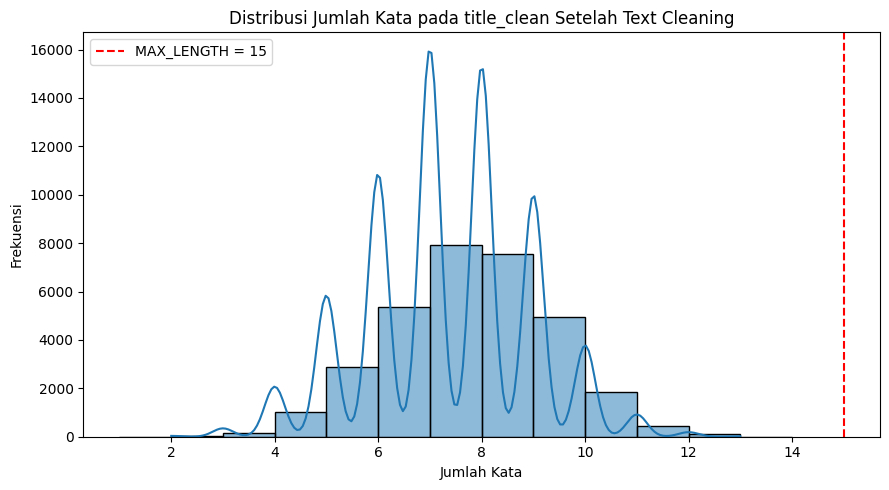

In [22]:
# menghitung jumlah kata pada title_clean, dipakai sebagai dasar validasi MAX_LENGTH di tahap padding
df['clean_word_count'] = df['title_clean'].apply(lambda x: len(x.split()))

print('Statistik jumlah kata title_clean (keseluruhan dataset):')
print(df['clean_word_count'].describe())
print()
print('Percentile 90 :', df['clean_word_count'].quantile(0.90))
print('Percentile 95 :', df['clean_word_count'].quantile(0.95))
print('Percentile 99 :', df['clean_word_count'].quantile(0.99))
print()

jumlah_terpotong = (df['clean_word_count'] > MAX_LENGTH).sum()
print(f'Jumlah judul dengan panjang lebih dari MAX_LENGTH ({MAX_LENGTH}): {jumlah_terpotong} ({jumlah_terpotong/len(df)*100:.4f}%)')

plt.figure(figsize=(9, 5))
sns.histplot(df['clean_word_count'], bins=range(1, df['clean_word_count'].max() + 2), kde=True)
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'MAX_LENGTH = {MAX_LENGTH}')
plt.title('Distribusi Jumlah Kata pada title_clean Setelah Text Cleaning')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.show()

**✦ Insight dari Distribusi Panjang Judul Setelah Text Cleaning**

Histogram menunjukkan distribusi jumlah kata pada title_clean memusat di sekitar 7 sampai 8 kata, dengan rata rata 7.32 kata dan standar deviasi 1.57. Ini lebih pendek dibanding distribusi title asli sebelum cleaning yang rata ratanya 8.6 kata, seperti yang sudah ditemukan di EDA sebelum Feature Engineering. Selisih sekitar 1.3 kata ini murni efek dari stopword removal, yang membuang kata kata seperti "yang", "di", "ke", dan sejenisnya, kata kata yang secara makna tidak banyak membantu membedakan kategori. Percentile 99 cuma di angka 11 kata, dan nilai maksimum keseluruhan cuma 13 kata. Dari sini bisa dipastikan MAX_LENGTH=15 yang sudah ditentukan sebelumnya adalah pilihan yang aman, terbukti dari 0 judul (0.0000 persen) yang panjangnya melebihi 15 kata, sehingga proses truncating sama sekali tidak menghilangkan informasi dari judul manapun. Konsekuensinya, ada ruang padding kosong yang lumayan besar untuk sebagian besar judul, karena rata rata cuma terisi sekitar 7 dari 15 slot yang tersedia. Ini bukan masalah serius mengingat angka MAX_LENGTH 15 masih tergolong kecil, jadi overhead komputasi dari padding berlebih ini bisa diabaikan.

##### 5.7.3 Analisis Vocabulary Coverage dan OOV Rate

In [23]:
# menghitung berapa persen token pada train, val, dan test yang jadi OOV
# tokenizer hanya di fit di data train, jadi val dan test berpotensi mengandung kata
# yang sama sekali belum pernah dilihat tokenizer, ini dicek langsung dari hasil texts_to_sequences
oov_index = tokenizer.word_index[tokenizer.oov_token]

def hitung_oov(seq_list):
    total_token = sum(len(seq) for seq in seq_list)
    total_oov = sum(seq.count(oov_index) for seq in seq_list)
    return total_oov, total_token, total_oov / total_token * 100

oov_train, total_train, rate_train = hitung_oov(X_train_seq)
oov_val, total_val, rate_val = hitung_oov(X_val_seq)
oov_test, total_test, rate_test = hitung_oov(X_test_seq)

print(f'OOV rate train : {oov_train}/{total_train} token = {rate_train:.4f}%')
print(f'OOV rate val   : {oov_val}/{total_val} token = {rate_val:.4f}%')
print(f'OOV rate test  : {oov_test}/{total_test} token = {rate_test:.4f}%')
print()

# menghitung persentase judul yang mengandung minimal satu kata OOV, dipecah per kategori
def judul_ada_oov(seq_list):
    return [oov_index in seq for seq in seq_list]

val_has_oov = pd.Series(judul_ada_oov(X_val_seq))
test_has_oov = pd.Series(judul_ada_oov(X_test_seq))

y_val_reset = y_val.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

valtest_has_oov = pd.concat([val_has_oov, test_has_oov], ignore_index=True)
valtest_category = pd.concat([y_val_reset, y_test_reset], ignore_index=True)

oov_per_kategori = (valtest_has_oov.groupby(valtest_category).mean() * 100).sort_values(ascending=False)
print('Persentase judul (val+test) yang mengandung minimal 1 kata OOV per kategori:')
print(oov_per_kategori.round(2))

OOV rate train : 4663/165730 token = 2.8136%
OOV rate val   : 2005/35468 token = 5.6530%
OOV rate test  : 2048/35408 token = 5.7840%

Persentase judul (val+test) yang mengandung minimal 1 kata OOV per kategori:
category
sport      43.84
travel     42.67
oto        33.66
health     31.89
finance    22.18
dtype: float64


**✦ Insight dari Analisis Vocabulary Coverage dan OOV Rate**

- OOV rate di train sendiri tercatat 2.81% (4.663 dari 165.730 token), murni karena batas VOCAB_SIZE=10000 memang sengaja memotong kata kata langka atau long tail, sesuai tujuan tokenizer untuk fokus ke kosakata yang benar benar informatif. Begitu masuk ke val dan test, OOV rate naik jadi 5.65 dan 5.78%. Kenaikan ini wajar terjadi karena tokenizer memang cuma di-fit di data train untuk mencegah data leakage, jadi val dan test pasti akan menemukan kata baru yang sama sekali belum pernah dilihat tokenizer, bukan sekadar soal batas vocab_size saja.

- Temuan yang lebih penting ada di breakdown per kategori. Sebanyak 43.84% judul sport dan 42.67% judul travel di gabungan val dan test mengandung minimal satu kata OOV, jauh di atas oto (33.66%), health (31.89%), dan finance (22.18%). Pola ini sejalan dengan ukuran data tiap kategori di train, finance yang datanya paling banyak (14.141 baris) justru OOV rate-nya paling rendah, sementara sport yang datanya paling sedikit (2.434 baris) OOV rate-nya paling tinggi. Semakin sedikit data training untuk satu kategori, semakin terbatas juga variasi kosakata yang sempat dipelajari tokenizer dari kategori tersebut, jadi wajar kalau judul baru dari kategori itu lebih sering menabrak kata yang belum dikenal model.

- Temuan ini melengkapi masalah vocabulary overlap yang sudah ditemukan di EDA sebelum Feature Engineering. Kalau nanti di tahap Model Evaluation ternyata sport atau travel memang jadi kategori dengan tingkat kesalahan klasifikasi yang tinggi, OOV rate yang tinggi di kedua kategori ini bisa jadi salah satu faktor penyebabnya, di luar soal kemiripan makna kata dengan kategori lain.

##### 5.7.4 WordCloud Long Tail Words per Kategori

Jumlah kata di long tail: 4662
Jumlah kata long tail yang cuma muncul 1 kali di seluruh train: 3106 (66.62%)



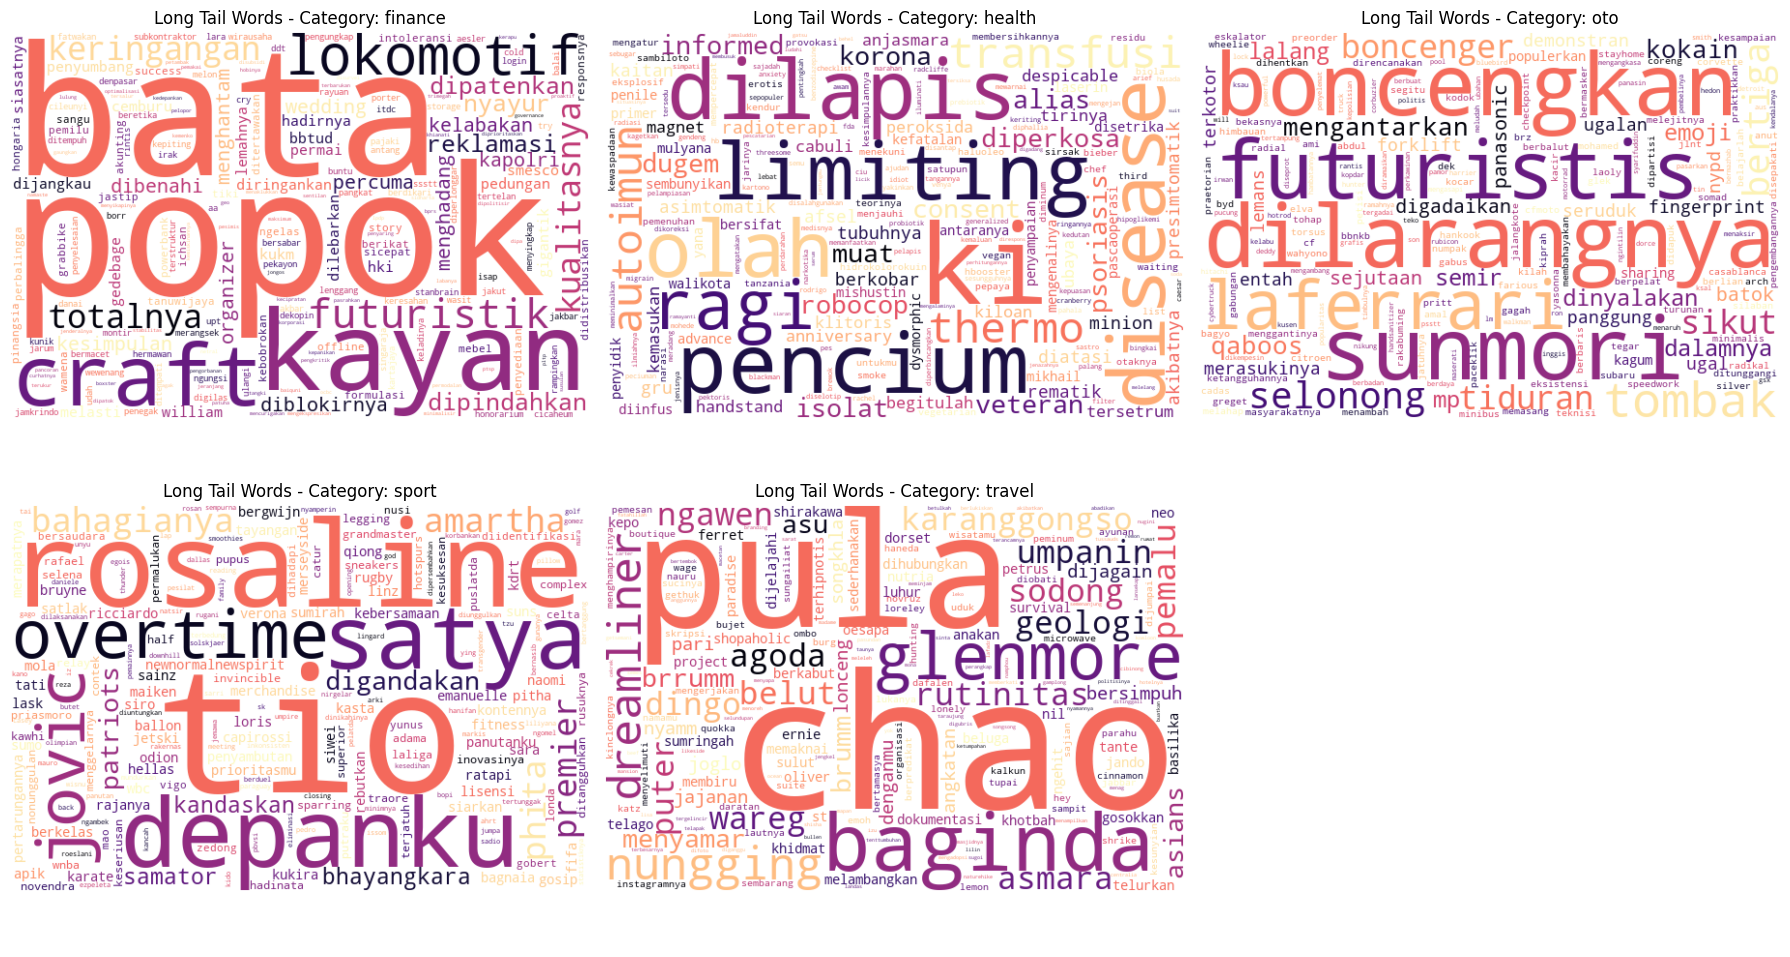

In [24]:
# hitung frekuensi setiap kata, lalu ambil daftar kata yang diurutkan dari yang paling sering muncul
sorted_words = [w for w, c in Counter([tok for title in X_train for tok in title.split()]).most_common()]

# LONG TAIL WORDS = kata kata yang terpotong karena batas VOCAB_SIZE
# kata kata ini akan jadi OOV bahkan di data train sendiri, sehingga divisualisasikan
# untuk melihat karakter kosakata yang hilang di tiap kategori
top_vocab = set(sorted_words[:VOCAB_SIZE - 1])
long_tail_words = set(sorted_words[VOCAB_SIZE - 1:])

frekuensi_long_tail = [frekuensi_kata[w] for w in long_tail_words]
jumlah_freq_1 = sum(1 for f in frekuensi_long_tail if f == 1)
print('Jumlah kata di long tail:', len(long_tail_words))
print(f'Jumlah kata long tail yang cuma muncul 1 kali di seluruh train: {jumlah_freq_1} ({jumlah_freq_1/len(long_tail_words)*100:.2f}%)')
print()

df_train_cek = pd.DataFrame({'title_clean': X_train.values, 'category': y_train.values})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(sorted(df_train_cek['category'].unique())):
    tokens_cat = [w for title in df_train_cek.loc[df_train_cek['category'] == cat, 'title_clean']
                  for w in title.split() if w in long_tail_words]
    text_combined = ' '.join(tokens_cat)
    wc = WordCloud(width=600, height=400, background_color='white', colormap='magma', random_state=88).generate(text_combined)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"Long Tail Words - Category: {cat}")
    axes[i].axis('off')

axes[5].axis('off')
plt.tight_layout()
plt.show()

**✦ Insight dari WordCloud Long Tail Words per Kategori**

- Dari 4.662 kata yang masuk long tail, sebanyak 3.106 kata (66.62%) memang cuma muncul 1 kali di seluruh data train, tapi sisanya, 1.556 kata (33.38%), sebenarnya muncul lebih dari 1 kali dan tetap saja tidak masuk top vocab. Artinya batas VOCAB_SIZE=10000 bukan cuma memotong kata kata yang benar benar unik sekali pakai, tapi juga sebagian kata yang sedikit berulang, meski jumlah pengulangannya masih kalah jauh dibanding puluhan ribu kata lain yang lebih sering muncul. Kata kata berukuran lebih besar di tiap wordcloud kemungkinan besar berasal dari kelompok 33.38% ini, karena WordCloud membesarkan ukuran font berdasarkan frekuensi relatif, sementara kata berukuran kecil di sekitar tepi biasanya representasi dari kelompok yang cuma muncul sekali.

- Secara visual, pola tiap kategori kelihatan cukup berbeda satu sama lain. Long tail sport, oto, dan travel didominasi entitas nama yang spesifik. Sport menampilkan rosaline, tio, bruyne, bhayangkara, dan ricciardo, semuanya nama pembalap, klub, atau liga olahraga. Oto menampilkan laferrari, panasonic, dan sunmori, campuran nama merek dan istilah komunitas otomotif. Travel menampilkan dreamliner dan agoda, istilah pesawat dan platform pemesanan travel yang spesifik. Sebaliknya, long tail finance justru didominasi kata kata umum seperti bata, popok, lokomotif, dan craft, bukan nama entitas spesifik. Health berada di tengah, campuran istilah medis seperti disease, psoriasis, radioterapi, dan transfusi dengan kata kata umum seperti olah dan ragi.

- Pola ini menunjukkan penyebab tingginya OOV rate ternyata berbeda beda antar kategori, bukan cuma satu sebab tunggal. Untuk sport, oto, dan travel, penyebab utamanya kemungkinan besar banyaknya entitas nama unik seperti atlet, merek, dan destinasi, yang secara alami jarang berulang persis sama dari satu judul ke judul lain. Untuk finance, penyebabnya kemungkinan lebih ke keragaman topik pemberitaan itu sendiri yang membuat kosakata umum jadi lebih variatif, bukan karena banyak entitas nama yang berbeda beda. Kedua penyebab ini sama sama berujung pada OOV rate yang tinggi, tapi kalau nanti mau diperbaiki, solusinya bisa beda, menaikkan VOCAB_SIZE mungkin cukup membantu untuk kasus finance yang variasinya lebih ke kosakata umum, tapi kurang membantu untuk sport, oto, dan travel yang akarnya ada di named entity yang memang akan terus muncul entitas baru meski datanya ditambah.

---

### **6. Model Definition (ANN Training)**
Pada tahap ini akan dibangun arsitektur ANN Training dengan beberapa langkah berikut ini:
1. Set random seed, supaya proses training bisa direproduksi ulang, sehingga hasil yang di dapat hari ini bisa konsisten bila dijalankan di lain waktu.
2. Didefinisikan arsitektur pakai Sequential API, terdiri dari Input layer, Embedding layer, GlobalAveragePooling1D, satu hidden Dense layer, Dropout, dan output Dense layer dengan softmax.
3. Cek model_1.summary(), untuk lihat shape tiap layer dan jumlah parameter, sekaligus sanity check sebelum masuk training.
4. Compile model, untuk menentukan optimizer, loss function, dan metric yang dipantau selama training.

In [25]:
# set seed supaya hasil training bisa direproduksi ulang
tf.random.set_seed(88)

VOCAB_SIZE = 10000
MAX_LENGTH = 15
EMBEDDING_DIM = 64
NUM_CLASSES = 5

# arsitektur ANN Training, sengaja dibuat simpel sebagai baseline
# embedding dilatih dari nol (bukan pretrained)
model_1 = Sequential([
    Input(shape=(MAX_LENGTH,), name='input_layer'),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='embedding_layer'),
    GlobalAveragePooling1D(name='global_average_pooling'),
    Dense(64, activation='relu', name='hidden_dense_1'),
    Dropout(0.3, name='dropout_1'),
    Dense(NUM_CLASSES, activation='softmax', name='output_layer')
])

model_1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ (None, 15, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_dense_1 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,485 (2.46 MB)

 Trainable params: 644,485 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

**✦ Insight dari Analisis Model Definition (ANN Training)**

- Arsitektur model_1 berhasil dibangun dengan total 644.485 parameter, seluruhnya berstatus trainable, tidak ada parameter non trainable maupun parameter yang dibawa dari model lain. Embedding_layer benar benar mulai belajar dari inisialisasi acak, bukan dari vector kata yang sudah jadi.

- Dari rincian layer, embedding_layer menyumbang 640.000 parameter, sementara hidden_dense_1 hanya 4.160 dan output_layer 325. Artinya lebih dari 99 persen kapasitas model ini terpakai untuk mempelajari representasi vector tiap kata (10.000 kata kali 64 dimensi), sedangkan bagian klasifikasinya sendiri (dua Dense layer terakhir) relatif ringan. Pola ini umum ditemui di model NLP berbasis embedding untuk vocabulary berukuran menengah dan jadi indikasi bahwa kualitas hasil klasifikasi nanti akan sangat bergantung pada seberapa baik embedding_layer ini berhasil menangkap pola kata selama training, mengingat porsi parameternya yang dominan.

- Layer global_average_pooling dan dropout_1 tidak punya parameter sama sekali (0), wajar karena keduanya cuma melakukan operasi matematis tetap (rata rata dan pengacakan neuron) tanpa ada bobot yang perlu dipelajari.

- Shape output tiap layer juga berjalan seperti yang direncanakan, dari (None, 15, 64) di embedding, menyusut jadi (None, 64) setelah pooling, tetap (None, 64) setelah hidden dense, sampai akhirnya (None, 5) di output layer sesuai jumlah kategori yang mau diklasifikasikan.

---

### **7. Model Training (ANN Training)**
Pada tahap ini akan dilakukan beberapa langkah untuk melakukan training model, berikut adalah langkah-langkahnya:
1. Setup Callback, pakai EarlyStopping monitor val_loss, patience=3, restore_best_weights=True. Alasannya supaya training otomatis berhenti kalau model mulai overfit (val_loss naik terus), dan kita tetap dapat bobot terbaik bukan bobot di epoch terakhir yang belum tentu optimal.
2. Skenario Eksperimen, dengan melakukan perubahan pada hyperparameter Tuning, yaitu:
    * Tuning 1 (Baseline): batch_size=32, epochs=30, learning rate default Adam (0.001).
    * Tuning 2 (Batch size lebih besar): batch_size=64, epochs dan lr sama seperti Tuning 1. Tujuannya lihat pengaruh batch size ke kecepatan training dan stabilitas kurva loss.
    * Tuning 3 (Learning rate lebih kecil): learning_rate=0.0005, batch_size sama seperti Tuning 1. Tujuannya lihat apakah training lebih stabil (tapi mungkin lebih lambat konvergen).
3. Simpan history tiap Tuning, supaya bisa diplot dan dibandingkan di Model Evaluation nanti.
4. Plot loss dan accuracy (train vs val) untuk tiap Tuning, Sebagai bukti visual tren training, dipakai buat analisis di Model Evaluation.

#### 7.1 Callback dan Fungsi Pembuatan Ulang Arsitektur

In [26]:
# EarlyStopping dipakai supaya training berhenti otomatis saat val_loss tidak membaik lagi
# restore_best_weights=True memastikan bobot yang dipakai adalah bobot terbaik selama training,
# bukan bobot di epoch terakhir yang bisa jadi sudah overfit
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Fungsi ini dipakai untuk membuat ulang arsitektur model_1 dari nol setiap kali mau training baru
# Tujuannya supaya setiap skenario hyperparameter dibandingkan dari kondisi bobot awal yang sama persis,
# bukan melanjutkan bobot dari skenario training sebelumnya
def build_model_1():
    tf.random.set_seed(88)
    model = Sequential([
        Input(shape=(MAX_LENGTH,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True, name='embedding_layer'),
        GlobalAveragePooling1D(name='global_average_pooling'),
        Dense(64, activation='relu', name='hidden_dense_1'),
        Dropout(0.3, name='dropout_1'),
        Dense(5, activation='softmax', name='output_layer')
    ])
    return model

#### 7.2 Training Tuning 1 (Baseline)

In [27]:
# Skenario 1, baseline
# batch_size 32, learning rate default Adam (0.001), epochs 30
model_1 = build_model_1()
model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_1 = model_1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6550 - loss: 1.1264 - val_accuracy: 0.8884 - val_loss: 0.3379
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9147 - loss: 0.2366 - val_accuracy: 0.8998 - val_loss: 0.3109
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9539 - loss: 0.1235 - val_accuracy: 0.9000 - val_loss: 0.3199
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9678 - loss: 0.0805 - val_accuracy: 0.8932 - val_loss: 0.3625
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9763 - loss: 0.0576 - val_accuracy: 0.8866 - val_loss: 0.4046


#### 7.3 Training Tuning 2 (Batch Size Lebih Besar)

In [28]:
# Skenario 2, batch_size dinaikkan jadi 64
# Tujuannya lihat pengaruh batch size lebih besar terhadap kecepatan training dan kestabilan kurva loss
# Tuning lain (learning rate, epochs) tetap sama seperti Tuning 1 supaya perbandingan adil
model_1b = build_model_1()
model_1b.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model_1b.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=64,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6449 - loss: 1.2736 - val_accuracy: 0.8861 - val_loss: 0.3669
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9069 - loss: 0.2798 - val_accuracy: 0.9018 - val_loss: 0.3049
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9453 - loss: 0.1484 - val_accuracy: 0.9022 - val_loss: 0.3058
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9627 - loss: 0.1003 - val_accuracy: 0.8979 - val_loss: 0.3251
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9730 - loss: 0.0691 - val_accuracy: 0.8950 - val_loss: 0.3488


#### 7.4 Training Tuning 3 (Learning Rate Lebih Kecil)

In [29]:
# Skenario 3, learning rate diturunkan jadi 0.0005 (default Adam adalah 0.001)
# Tujuannya lihat apakah training jadi lebih stabil meski kemungkinan butuh epoch lebih banyak untuk konvergen
# batch_size dikembalikan ke 32 seperti Tuning 1 supaya hanya learning rate yang jadi variabel pembeda
model_1c = build_model_1()
model_1c.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

history_3 = model_1c.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5864 - loss: 1.3557 - val_accuracy: 0.8779 - val_loss: 0.4077
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8983 - loss: 0.3316 - val_accuracy: 0.8981 - val_loss: 0.3076
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9380 - loss: 0.1773 - val_accuracy: 0.9024 - val_loss: 0.3007
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9564 - loss: 0.1177 - val_accuracy: 0.9043 - val_loss: 0.3013
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9669 - loss: 0.0874 - val_accuracy: 0.9022 - val_loss: 0.3159
Epoch 6/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9735 - loss: 0.0661 - val_accuracy: 0.9016 - val_loss: 0.3374


#### 7.5 Plot Kurva Loss dan Accuracy (Train vs Val) untuk Ketiga Tuning

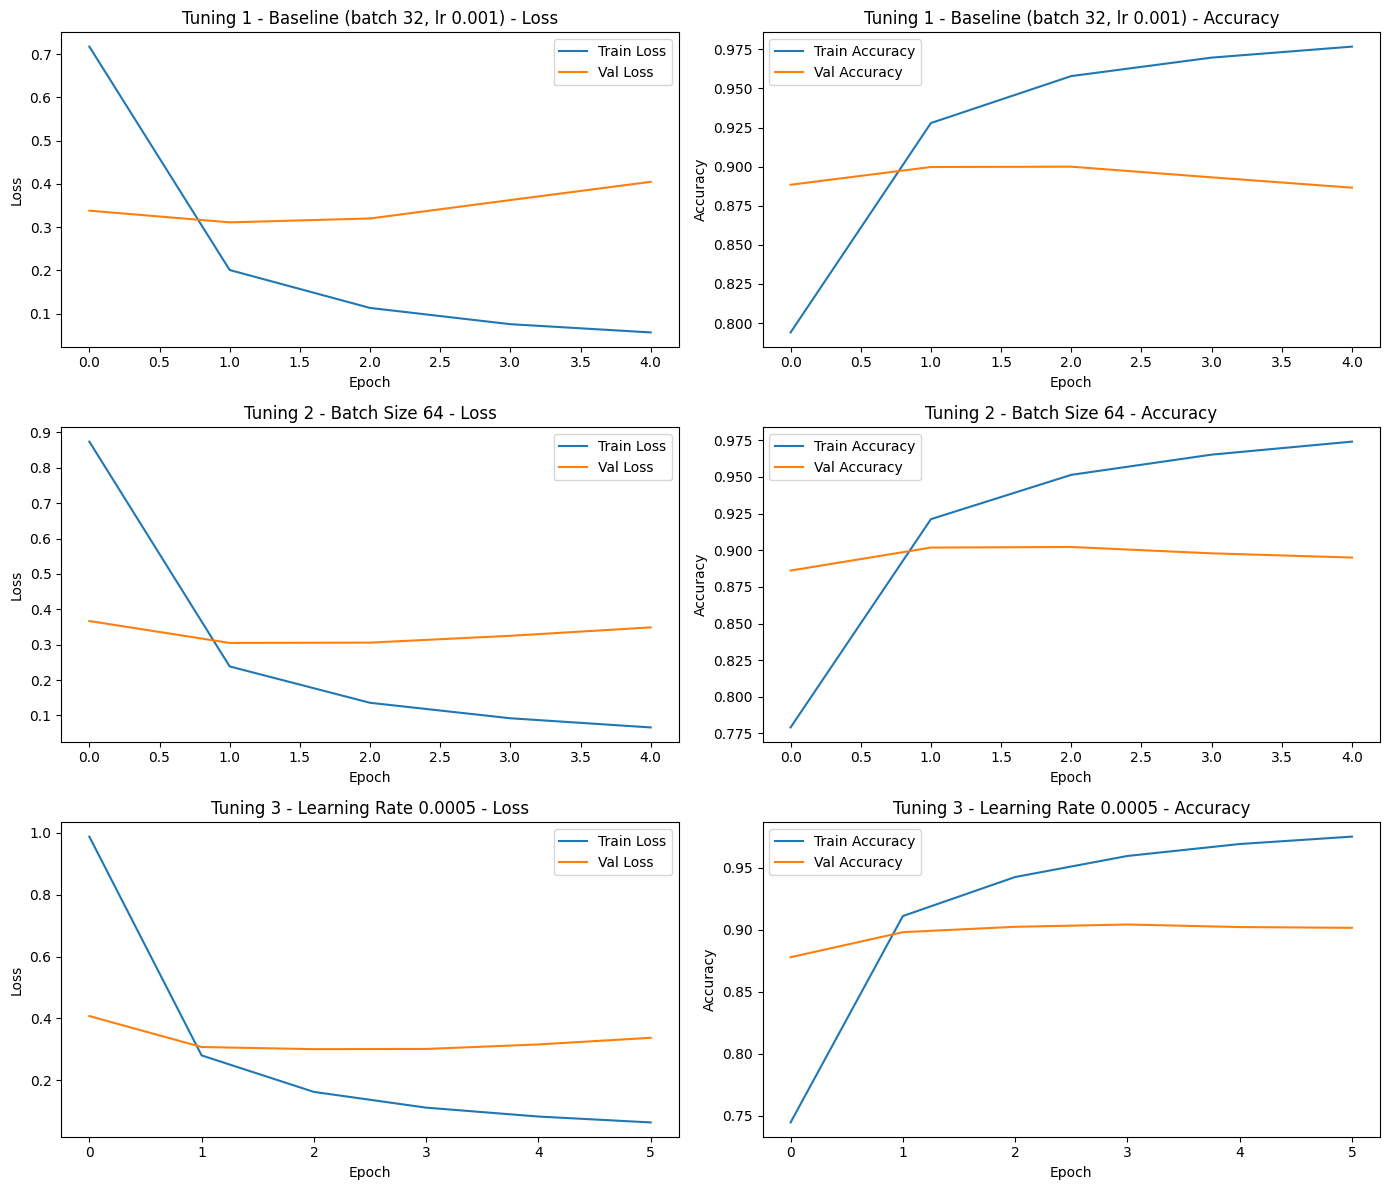

In [30]:
# Visualisasi tren loss dan accuracy untuk train dan val di ketiga Tuning
# Dipakai sebagai bukti visual saat analisis di bagian Model Evaluation
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

runs = [
    (history_1, 'Tuning 1 - Baseline (batch 32, lr 0.001)'),
    (history_2, 'Tuning 2 - Batch Size 64'),
    (history_3, 'Tuning 3 - Learning Rate 0.0005')
]

for i, (hist, label) in enumerate(runs):
    axes[i, 0].plot(hist.history['loss'], label='Train Loss')
    axes[i, 0].plot(hist.history['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{label} - Loss')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['accuracy'], label='Train Accuracy')
    axes[i, 1].plot(hist.history['val_accuracy'], label='Val Accuracy')
    axes[i, 1].set_title(f'{label} - Accuracy')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

**✦ Insight dari Visualisasi Kurva Loss dan Accuracy (ANN Training)**
1. Analisis Kurva Loss dan Accuracy (Train vs Val) untuk Ketiga Skenario Tuning
<br>Ketiga skenario tuning menunjukkan pola dasar yang sama, train loss terus menurun secara konsisten sepanjang training, sementara val loss membentuk kurva berbentuk U, turun di awal lalu berbalik naik setelah mencapai titik terendahnya. Pola ini adalah tanda klasik overfitting, model semakin menyesuaikan diri dengan data train tapi kemampuan generalisasinya ke data yang belum pernah dilihat justru mulai menurun begitu melewati titik optimalnya.

2. Tuning 1, Baseline (batch 32, learning rate 0.001)
<br>Training berhenti di epoch 5 karena EarlyStopping aktif. Val loss mencapai titik terendah di epoch 2 (0.31), setelah itu naik cukup tajam sampai mendekati 0.40 di epoch 5. Train accuracy melonjak dari sekitar 0.65 di epoch pertama menjadi 0.97 di epoch terakhir, sementara val accuracy relatif datar di kisaran 0.88 dan bahkan sedikit menurun menjelang epoch akhir. Gap yang melebar antara kurva train dan val, baik di grafik loss maupun accuracy, jadi bukti visual paling jelas bahwa model mulai overfit sejak epoch kedua.

3. Tuning 2, Batch Size 64
<br>Polanya serupa, val loss terendah juga di epoch 2 (sekitar 0.30) sebelum naik lagi ke sekitar 0.34 di epoch 5. Yang membedakan dari Tuning 1, val accuracy di Tuning 2 mengalami kenaikan dari 0.88 di epoch pertama menjadi 0.89 di epoch terakhir.

4. Tuning 3, Learning Rate 0.0005
<br>Training berhenti paling lama di antara ketiganya, yaitu epoch 6, karena learning rate yang lebih kecil membuat proses belajar berjalan lebih perlahan. Val loss terendah baru tercapai di epoch 3 (sekitar 0.300), satu epoch lebih lambat dibanding dua tuning lainnya. Val accuracy mengalami kenaikan paling tinggi diantara tuning1 dan tuning 2 dengan val accuracy terakhir di angka 0.90.

> **Kesimpulan dari Grafik,**
> Ketiga grafik ini menunjukkan hal yang sama, arsitektur model_1 konvergen sangat cepat untuk permasalahan klasifikasi lima kategori ini, ditandai dengan EarlyStopping yang aktif jauh sebelum mendekati batas 30 epoch yang ditentukan di awal. Learning rate yang lebih kecil di Tuning 3 memang memperlambat munculnya overfitting sekitar satu epoch dan membuat kenaikan val loss setelah titik terbaik lebih terkendali, tapi tidak menghilangkan pola overfitting itu sendiri. Ini memperkuat dugaan bahwa penyebab utama cepatnya overfitting bukan semata dari learning rate, melainkan lebih ke kombinasi arsitektur yang sederhana dengan jumlah data train yang terbatas (22.622 baris), ditambah pengaruh class_weight yang sengaja memperbesar sinyal gradien dari kelas minoritas seperti sport.

### **8. Model Evaluation (ANN Training)**
Model evaluasi dilakukan dengan beberapa tahapan sebagai berikut:
1. Evaluasi model dengan hyperparameter yang berbeda menggunakan classification_report dari sklearn untuk dapat precision, recall, F1 per kategori, plus F1 macro sebagai metrik pembanding utama.
2. Label dikembalikan ke nama asli (finance, health, oto, sport, travel) pakai label_encoder.classes_, bukan angka 0-4.
3. Macro F1 diambil khusus sebagai metric utama pembanding, karena tidak bias ke kelas mayoritas seperti finance.
4. Confusion matrix divisualisasikan pakai heatmap seaborn untuk tiap eksperimen, supaya kelihatan kategori mana yang paling sering tertukar.
5. Tabel ringkasan macro F1 ketiga eksperimen, untuk menentukan mana yang akan dibawa sebagai representasi terbaik ANN Training yang nantinya menjadi pembanding ANN Improvement.

#### 8.1 Fungsi Evaluasi (Classification Report dan Confusion Matrix)

In [31]:
# Fungsi ini dipakai berulang untuk evaluasi tiap eksperimen
# Menghasilkan classification report (precision, recall, F1 per kategori dan macro avg)
# serta confusion matrix dengan label kategori asli, bukan angka encoding
def evaluate_model(model, X_eval, y_eval_cat, hype_name, label_encoder):
    # Prediksi probabilitas lalu ambil kelas dengan probabilitas tertinggi
    y_pred_prob = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_eval_cat, axis=1)

    print(f"=== Classification Report - {hype_name} ===")
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        digits=4,
        output_dict=True
    )
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

    # Confusion matrix pakai label kategori asli, bukan angka
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix - {hype_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    return report['macro avg']['f1-score']

#### 8.2 Evaluasi Ketiga Eksperimen di Validation Set

=== Classification Report - Tuning 1 - Baseline ===
              precision    recall  f1-score   support

     finance     0.9554    0.8991    0.9264      2121
      health     0.8804    0.9186    0.8991       737
         oto     0.8394    0.8828    0.8605       657
       sport     0.8673    0.9315    0.8983       365
      travel     0.8580    0.8864    0.8720       968

    accuracy                         0.8998      4848
   macro avg     0.8801    0.9037    0.8912      4848
weighted avg     0.9022    0.8998    0.9003      4848



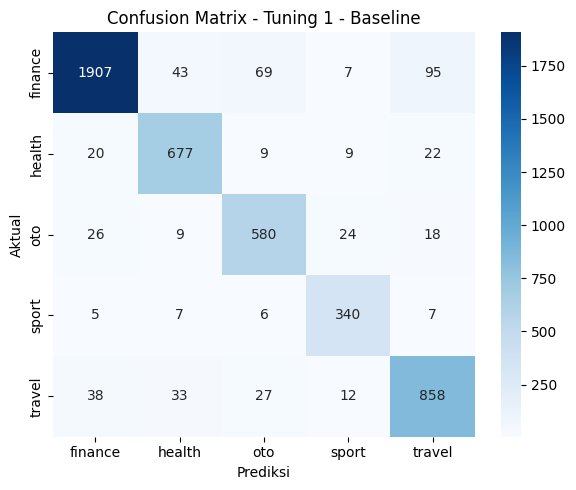

=== Classification Report - Tuning 2 - Batch Size 64 ===
              precision    recall  f1-score   support

     finance     0.9590    0.9048    0.9311      2121
      health     0.8886    0.9091    0.8987       737
         oto     0.8413    0.8874    0.8637       657
       sport     0.8571    0.9205    0.8877       365
      travel     0.8571    0.8926    0.8745       968

    accuracy                         0.9018      4848
   macro avg     0.8806    0.9029    0.8911      4848
weighted avg     0.9043    0.9018    0.9025      4848



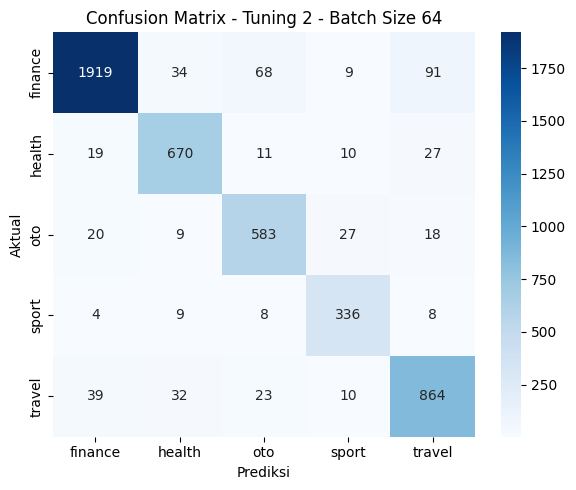

=== Classification Report - Tuning 3 - Learning Rate 0.0005 ===
              precision    recall  f1-score   support

     finance     0.9566    0.9043    0.9297      2121
      health     0.8805    0.9199    0.8998       737
         oto     0.8420    0.8843    0.8627       657
       sport     0.8737    0.9096    0.8913       365
      travel     0.8634    0.8946    0.8787       968

    accuracy                         0.9024      4848
   macro avg     0.8833    0.9026    0.8924      4848
weighted avg     0.9047    0.9024    0.9030      4848



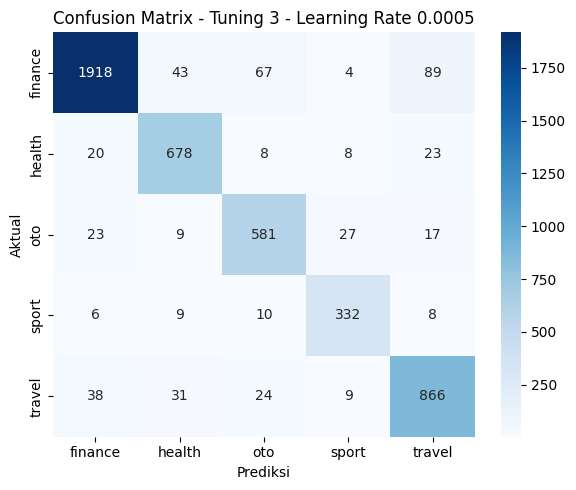

Ringkasan F1 Macro (Validation Set)
Tuning 1 (Baseline)          : 0.8912
Tuning 2 (Batch Size 64)     : 0.8911
Tuning 3 (Learning Rate)     : 0.8924


In [32]:
# Evaluasi ketiga model eksperimen hasil training di validation set
# Dipakai untuk membandingkan performa antar hyperparameter, bukan evaluasi final
f1_macro_tun1 = evaluate_model(model_1, X_val_pad, y_val_cat, 'Tuning 1 - Baseline', label_encoder)
f1_macro_tun2 = evaluate_model(model_1b, X_val_pad, y_val_cat, 'Tuning 2 - Batch Size 64', label_encoder)
f1_macro_tun3 = evaluate_model(model_1c, X_val_pad, y_val_cat, 'Tuning 3 - Learning Rate 0.0005', label_encoder)

print("Ringkasan F1 Macro (Validation Set)")
print(f"Tuning 1 (Baseline)          : {f1_macro_tun1:.4f}")
print(f"Tuning 2 (Batch Size 64)     : {f1_macro_tun2:.4f}")
print(f"Tuning 3 (Learning Rate)     : {f1_macro_tun3:.4f}")

**✦ Insight dari Perbandingan Ketiga Eksperimen Tuning di Validation Set**

1. Ketiga eksperimen menghasilkan performa yang **sangat berdekatan**, dengan selisih **F1 Macro** antara model terbaik dan terendah hanya sekitar **0.0012**. Hal ini menunjukkan bahwa perubahan hyperparameter yang dilakukan belum memberikan perbedaan performa yang signifikan. 

2. Analisis confusion matrix menunjukkan bahwa terdapat dua pola kesalahan utama yang muncul secara konsisten pada ketiga eksperimen. Konsistensi ini mengindikasikan bahwa kesalahan tersebut bukan disebabkan oleh variasi proses training, melainkan merupakan karakteristik dari model dan dataset yang digunakan.
  * Finance sering tertukar dengan Travel, Pasangan kesalahan terbesar pada seluruh eksperimen terjadi antara kategori **Finance** dan **Travel**. Kemungkinan penyebabnya, berita seputar sektor pariwisata sering dibahas dari sudut pandang ekonomi (dampak ke devisa, investasi hotel, harga tiket), jadi vocabulary-nya bersinggungan dengan finance.

    | Kesalahan | Tuning 1 | Tuning 2 | Tuning 3 |
    |-----------|------:|------:|------:|
    | Finance → Travel | 95 | 91 | 89 |
    | Travel → Finance | 38 | 39 | 38 |

  * Finance sering diprediksi sebagai Oto, pola ini bersifat **satu arah**. Berita Finance cukup sering diklasifikasikan sebagai Oto, tetapi berita Oto relatif sedikit diprediksi sebagai Finance. Kemungkinan berita finance yang membahas industri otomotif (harga saham perusahaan mobil, penjualan kendaraan, pajak kendaraan) punya vocabulary yang mirip kategori oto, tapi tidak berlaku sebaliknya karena berita oto jarang membahas topik keuangan murni.

3. Salah satu tujuan penggunaan **class_weight** pada tahap Feature Engineering adalah mengurangi bias model terhadap kelas mayoritas. Hasil evaluasi menunjukkan bahwa kategori **Sport**, yang hanya memiliki **365 data** pada validation set (support terkecil di antara lima kategori), justru memperoleh nilai **recall tertinggi** secara konsisten pada seluruh eksperimen.

    | Tuning | Recall Sport |
    |-----|-------------:|
    | Tuning 1 | **0.9315** |
    | Tuning 2 | **0.9205** |
    | Tuning 3 | **0.9096** |

    Temuan ini menunjukkan bahwa penerapan **class_weight** berhasil membantu model mengenali kelas minoritas dengan baik. Tanpa penggunaan **class_weight**, kelas dengan jumlah data paling sedikit umumnya lebih rentan memiliki recall yang rendah karena kontribusi sinyal gradiennya kalah dominan dibandingkan kelas mayoritas, terutama kategori **Finance** yang memiliki jumlah data sekitar **5.8 kali lebih banyak** dibandingkan kategori Sport.

4. Rekomendasi Model Terbaik, Walaupun selisih performa antar eksperimen sangat kecil (**F1 Macro hanya berbeda sekitar 0.0012**), secara praktis ketiga model dapat dianggap memiliki performa yang setara. Namun, agar proses pemilihan model akhir tetap objektif dan dapat dipertanggungjawabkan, **model_1c Tuning 3** direkomendasikan sebagai model representatif hasil pelatihan ANN dengan pertimbangan sebagai berikut:
    *  Memiliki **F1 Macro tertinggi (0.8924)**.
    * Memiliki **Accuracy tertinggi (0.9024)**.
    * Memberikan performa yang paling konsisten pada validation set.

#### 8.3 Evaluasi Final di Test Set (ANN Training)

=== Classification Report - ANN Training Final - Test Set ===
              precision    recall  f1-score   support

     finance     0.9547    0.8930    0.9228      2122
      health     0.8444    0.9281    0.8843       737
         oto     0.8710    0.8750    0.8730       656
       sport     0.8561    0.9288    0.8909       365
      travel     0.8637    0.8905    0.8769       968

    accuracy                         0.8981      4848
   macro avg     0.8780    0.9031    0.8896      4848
weighted avg     0.9010    0.8981    0.8987      4848



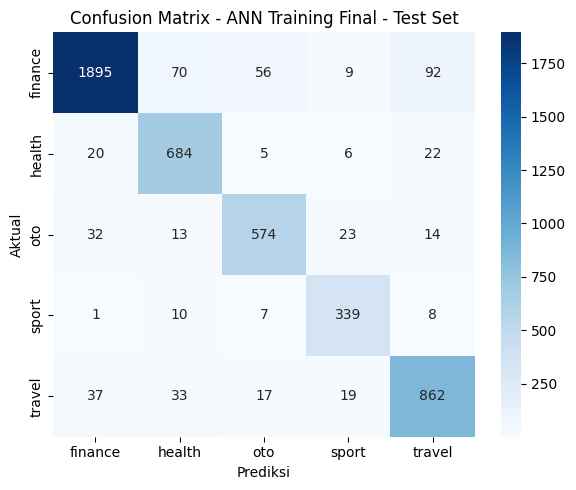

F1 Macro di Test Set : 0.8896


In [33]:
# Evaluasi model_1c (Tuning 3, Learning Rate 0.0005) di test set
# Ini laporan performa final dan resmi untuk ANN Training, dipakai sebagai pembanding ANN Improvement nanti
# Fungsi evaluate_model yang sama dari evaluasi val set dipakai lagi supaya konsisten
f1_macro_test = evaluate_model(model_1c, X_test_pad, y_test_cat, 'ANN Training Final - Test Set', label_encoder)

print(f"F1 Macro di Test Set : {f1_macro_test:.4f}")

**✦ Insight dari Performa Final ANN Training di Test Set**

1. Performa pada test set hanya mengalami sedikit penurunan dibandingkan validation set, yaitu sekitar **0.0043** pada Accuracy dan **0.0028** pada F1 Macro. Penurunan sekecil ini merupakan kondisi yang wajar dan justru menjadi indikator bahwa model memiliki **kemampuan generalisasi yang baik**. Hal ini karena test set sama sekali **tidak digunakan** selama proses pelatihan maupun pemilihan hyperparameter, sehingga hasil evaluasi pada data tersebut memberikan gambaran yang lebih objektif mengenai performa model pada data baru. Dengan demikian, **tidak** terdapat indikasi bahwa model mengalami **overfitting** terhadap validation set.

2. Jika dilihat berdasarkan masing-masing kategori, penurunan performa tidak terjadi secara merata. Kategori **Health** mengalami penurunan F1 Score dari **0.8998** menjadi **0.8843**, sedangkan kategori **Sport** turun dari **0.8913** menjadi **0.8909** Sebaliknya, kategori **Oto** menunjukkan performa yang baik dengan kenaikan yang cukup signifikan, yaitu dari **0.8627** menjadi **0.8730**.

3. Analisis confusion matrix pada test set menunjukkan bahwa pola kesalahan yang sebelumnya ditemukan pada validation set kembali muncul secara konsisten. Hal ini mengindikasikan bahwa pola tersebut merupakan karakteristik dari model, bukan sekadar akibat pembagian data tertentu.
    * Finance dan travel masih paling sering tertukar. Finance salah diprediksi travel ada 92 kasus, travel salah diprediksi finance ada 37 kasus. Ini tetap jadi pasangan kesalahan terbesar, konsisten dengan dugaan sebelumnya bahwa berita seputar sektor pariwisata sering dibingkai dari sudut ekonomi sehingga vocabulary-nya tumpang tindih dengan finance.
    * Finance juga masih banyak ketukar dengan health (70 kasus finance diprediksi health) dan Finance juga masih banyak ketukar dengan hoto (56 kasus finance diprediksi oto) . Perlu dicatat bahwa pola ini tetap ada tapi tidak setegas di val set, kemungkinan karena ukuran sampel test set yang lebih kecil membuat rasio kesalahan lebih mudah bergeser.

>> Nilai **F1 Macro sebesar 0.8896** selanjutnya digunakan sebagai **baseline utama** untuk tahap **ANN Improvement**.

---

### **9. Model Definition (ANN Improvement)**
Pada tahap ini akan dibangun arsitektur ANN Improvement dengan beberapa langkah berikut ini:
1. Set random seed, supaya proses training bisa direproduksi ulang, sehingga hasil yang didapat konsisten.
2. Didefinisikan arsitektur pakai Functional API, terdiri dari Input layer, Embedding layer, SpatialDropout1D, tiga cabang Conv1D paralel dengan kernel_size berbeda untuk menangkap pola bigram, trigram, dan four-gram, GlobalMaxPooling1D pada tiap cabang, Concatenate, satu hidden Dense layer, Dropout, dan output Dense layer dengan softmax.
3. Cek model_2.summary(), untuk lihat shape tiap layer dan jumlah parameter, sekaligus sanity check sebelum masuk training.
4. Compile model, untuk menentukan optimizer, loss function, dan metric yang dipantau selama training.

In [34]:
# konfigurasi arsitektur ANN Improvement, disamakan dengan konfigurasi feature engineering sebelumnya
VOCAB_SIZE = 10000
MAX_LENGTH = 15

# fungsi untuk membangun arsitektur ANN Improvement (TextCNN dengan Functional API)
# tf.random.set_seed dipanggil di awal supaya tiap skenario training nanti dimulai dari bobot awal yang sama
def build_model_2(vocab_size=VOCAB_SIZE, max_length=MAX_LENGTH, embed_dim=64,
                   filter_sizes=(2, 3, 4), num_filters=64, dense_units=64, dropout_rate=0.5, seed=88):
    tf.random.set_seed(seed)

    input_layer = Input(shape=(max_length,), name='input_title')

    # embedding dilatih dari nol (bukan pretrained), dimensi disamakan dengan model_1
    # supaya perbedaan performa nanti murni disebabkan oleh perbedaan arsitektur
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=embed_dim, name='embedding')(input_layer)

    # spatial dropout mematikan satu channel embedding secara utuh, bukan elemen acak satu-satu
    # cocok untuk teks karena antar dimensi embedding saling berkorelasi kuat
    embedding_layer = SpatialDropout1D(0.2, name='spatial_dropout')(embedding_layer)

    # tiga cabang convolution paralel, tiap cabang menangkap pola n-gram yang berbeda
    # kernel_size 2 untuk pola bigram, 3 untuk trigram, 4 untuk four-gram
    # pilihan ini langsung menyasar temuan EDA bahwa bigram/trigram lebih diskriminatif dibanding unigram
    conv_branches = []
    for k in filter_sizes:
        conv = Conv1D(filters=num_filters, kernel_size=k, activation='relu', name=f'conv1d_k{k}')(embedding_layer)
        pool = GlobalMaxPooling1D(name=f'global_max_pool_k{k}')(conv)
        conv_branches.append(pool)

    # gabungkan feature n-gram dari ketiga cabang jadi satu vector representasi judul berita
    concatenated = Concatenate(name='concat_ngram_features')(conv_branches)

    # dense layer untuk mengombinasikan feature n-gram sebelum klasifikasi akhir
    dense_layer = Dense(dense_units, activation='relu', name='dense_combine')(concatenated)
    dense_layer = Dropout(dropout_rate, name='dropout')(dense_layer)

    # output layer 5 kelas dengan softmax, sama seperti model_1
    output_layer = Dense(5, activation='softmax', name='output')(dense_layer)

    model = Model(inputs=input_layer, outputs=output_layer, name='model_2_textcnn')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_2 = build_model_2()
model_2.summary()

Model: "model_2_textcnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_title         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 15, 64)    │    640,000 │ input_title[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 15, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k2 (Conv1D)  │ (None, 14, 64)    │      8,256 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k3 (Conv1D)  │ (None, 13, 64)    │     12,352 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k4 (Conv1D)  │ (None, 12, 64)    │     16,448 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k2  │ (None, 64)        │          0 │ conv1d_k2[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k3  │ (None, 64)        │          0 │ conv1d_k3[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k4  │ (None, 64)        │          0 │ conv1d_k4[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_ngram_featu… │ (None, 192)       │          0 │ global_max_pool_… │
│ (Concatenate)       │                   │            │ global_max_pool_… │
│                     │                   │            │ global_max_pool_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_combine       │ (None, 64)        │     12,352 │ concat_ngram_fea… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_combine[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 689,733 (2.63 MB)

 Trainable params: 689,733 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

**✦ Insight dari Analisis Model Definition (ANN Improvement)**
* Arsitektur model_2 berhasil dibangun dengan total 689.733 parameter, seluruhnya berstatus trainable, tidak ada non trainable parameter maupun bobot yang dibawa dari pretrained embedding manapun. Sama seperti model_1, embedding_layer di sini juga mulai belajar dari inisialisasi acak, jadi perbandingan performa nanti murni karena perbedaan arsitektur, bukan karena representasi kata awal yang sudah berbeda duluan.
* Distribusi parameter di model_2 jauh lebih tersebar dibanding model_1. Embedding_layer tetap jadi penyumbang terbesar dengan 640.000 parameter, tapi kali ini tiga cabang conv1d_k2, conv1d_k3, dan conv1d_k4 menyumbang total 37.056 parameter, ditambah dense_combine sebesar 12.352 parameter. Model_2 memang sengaja dirancang supaya sebagian kapasitas parameternya benar benar terpakai untuk mempelajari pola n-gram dan mengombinasikannya, bukan cuma numpang lewat setelah proses pooling seperti di model_1.
* Ketiga conv1d layer punya jumlah parameter yang naik berurutan mengikuti kernel_size nya, conv1d_k2 sebanyak 8.256, conv1d_k3 sebanyak 12.352, conv1d_k4 sebanyak 16.448. Pola ini konsisten dengan cara kerja Conv1D, semakin besar kernel_size maka semakin banyak posisi embedding berurutan yang dilihat sekaligus oleh satu filter, sehingga jumlah bobotnya naik proporsional (kernel_size dikali dimensi embedding dikali jumlah filter, ditambah bias per filter).
* Layer spatial_dropout dan ketiga global_max_pool tidak punya parameter sama sekali (0), sama seperti pooling dan dropout di model_1, karena keduanya cuma operasi tetap tanpa bobot yang perlu dipelajari.
* Dibandingkan model_1 yang punya 644.485 parameter, model_2 sedikit lebih besar dengan selisih 45.248 parameter atau sekitar 7% lebih banyak. Selisih ini karena adanya tiga cabang convolution paralel ditambah dense_combine yang menerima input 192 dimensi hasil gabungan tiga cabang, dibanding hidden_dense_1 di model_1 yang cuma menerima input 64 dimensi dari satu hasil pooling. Perbedaan ukuran ini belum bisa dipakai untuk menyimpulkan model mana yang lebih baik, karena penilaian utama tetap mengacu ke F1 macro hasil training dan evaluation, bukan ke jumlah parameter semata.

### **10. Model Training (ANN Improvement)**
Pada tahap ini akan dilakukan beberapa langkah untuk melakukan training model ANN Improvement, berikut adalah langkah-langkahnya:
1. Tuning 1 - model_2 (baseline): num_filters=64, dropout_rate=0.5, konfigurasi default hasil Model Definition pada ANN Training.
2. Tuning 2 / model_2b (num_filters=128): menaikkan jumlah filter per cabang convolution, menguji apakah kapasitas menangkap variasi pola n-gram yang lebih banyak membantu memisahkan kategori yang selama ini sering ketuker (finance-travel, finance-oto).
3. Tuning 3 / model_2c (dropout_rate=0.3): menurunkan dropout di dense layer. Model_2 sebenarnya sudah punya dua lapis regularisasi sekaligus (spatial_dropout 0.2 di embedding, dropout 0.5 di dense), eksperimen ini menguji apakah kombinasi regularisasi tersebut justru terlalu ketat untuk arsitektur yang kapasitas parameternya lebih tersebar dibanding model_1.
4. Konfigurasi training disamakan persis dengan ANN Training supaya perbandingan adil: EarlyStopping dengan monitor='val_loss', patience=3, restore_best_weights=True, epochs=30 sebagai batas atas, class_weight=class_weight_dict, dan validation_data=(X_val_pad, y_val_cat).
5. Plot loss dan accuracy (train vs val) untuk tiap Tuning, Sebagai bukti visual tren training, dipakai buat analisis di Model Evaluation.

#### 10.1 Tuning 1 - ANN Improvement

In [35]:
# Tuning 1: model_2 baseline, konfigurasi default dari Model Definition
model_2 = build_model_2(num_filters=64, dropout_rate=0.5)
early_stop_2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_2 = model_2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[early_stop_2]
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5390 - loss: 1.1915 - val_accuracy: 0.8847 - val_loss: 0.3406
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8992 - loss: 0.3046 - val_accuracy: 0.8886 - val_loss: 0.3355
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9444 - loss: 0.1628 - val_accuracy: 0.8962 - val_loss: 0.3413
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9591 - loss: 0.1095 - val_accuracy: 0.9016 - val_loss: 0.3958
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9720 - loss: 0.0733 - val_accuracy: 0.8973 - val_loss: 0.4281


#### 10.2 Tuning 2 - ANN Improvement

In [36]:
# Tuning 2: model_2b, num_filters dinaikkan jadi 128 untuk menambah kapasitas menangkap variasi pola n-gram
model_2b = build_model_2(num_filters=128, dropout_rate=0.5)
early_stop_2b = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_2b = model_2b.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[early_stop_2b]
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.5278 - loss: 1.1908 - val_accuracy: 0.8872 - val_loss: 0.3525
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8939 - loss: 0.3327 - val_accuracy: 0.8965 - val_loss: 0.3284
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9383 - loss: 0.1860 - val_accuracy: 0.8927 - val_loss: 0.3692
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9558 - loss: 0.1240 - val_accuracy: 0.8979 - val_loss: 0.4016
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9690 - loss: 0.0772 - val_accuracy: 0.8973 - val_loss: 0.4668


#### 10.3 Tuning 3 - ANN Improvement

In [37]:
# Tuning 3: model_2c, dropout_rate diturunkan jadi 0.3 karena model_2 sudah punya dua lapis regularisasi
# (spatial_dropout 0.2 di embedding, dropout 0.5 di dense), skenario ini menguji apakah kombinasi
# regularisasi tersebut terlalu ketat untuk arsitektur dengan kapasitas yang lebih tersebar ini
model_2c = build_model_2(num_filters=64, dropout_rate=0.3)
early_stop_2c = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_2c = model_2c.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict,
    callbacks=[early_stop_2c]
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5508 - loss: 1.1106 - val_accuracy: 0.8886 - val_loss: 0.3454
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9082 - loss: 0.2702 - val_accuracy: 0.8973 - val_loss: 0.3237
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9500 - loss: 0.1408 - val_accuracy: 0.9012 - val_loss: 0.3522
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9684 - loss: 0.0796 - val_accuracy: 0.8921 - val_loss: 0.4039
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9798 - loss: 0.0523 - val_accuracy: 0.8969 - val_loss: 0.4512


#### 10.4 Plot Kurva Loss dan Accuracy (Train vs Val) untuk Ketiga Tuning

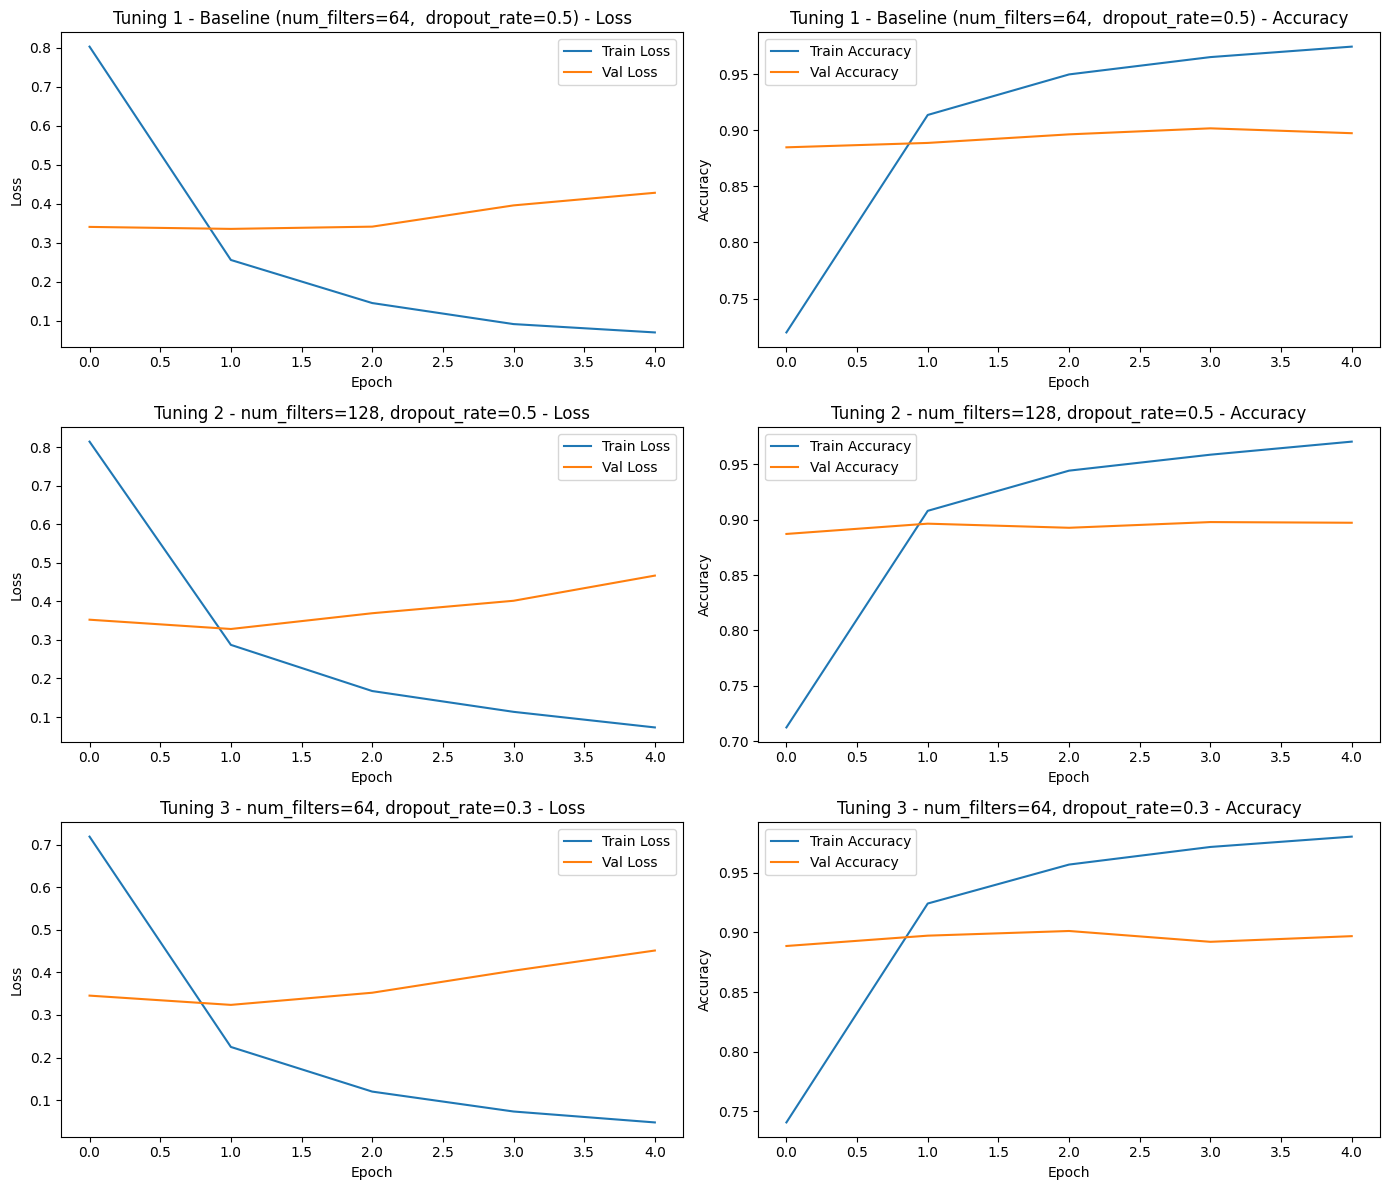

In [38]:
# Visualisasi tren loss dan accuracy untuk train dan val di ketiga Tuning
# Dipakai sebagai bukti visual saat analisis di bagian Model Evaluation
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

runs = [
    (history_2, 'Tuning 1 - Baseline (num_filters=64,  dropout_rate=0.5)'),
    (history_2b, 'Tuning 2 - num_filters=128, dropout_rate=0.5'),
    (history_2c, 'Tuning 3 - num_filters=64, dropout_rate=0.3')
]

for i, (hist, label) in enumerate(runs):
    axes[i, 0].plot(hist.history['loss'], label='Train Loss')
    axes[i, 0].plot(hist.history['val_loss'], label='Val Loss')
    axes[i, 0].set_title(f'{label} - Loss')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['accuracy'], label='Train Accuracy')
    axes[i, 1].plot(hist.history['val_accuracy'], label='Val Accuracy')
    axes[i, 1].set_title(f'{label} - Accuracy')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

**✦ Insight dari Visualisasi Kurva Loss dan Accuracy (ANN Improvement)**
- Ketiga eksperimen tuning menunjukkan pola training yang konsisten, val_loss mencapai titik terendah di epoch 2 (Tuning 1 sebesar 0.3355, Tuning 2 sebesar 0.3284, Tuning 3 sebesar 0.3237), lalu terus naik sampai training dihentikan di epoch 5 oleh EarlyStopping dengan patience 3, dan bobot terbaik yang dikembalikan tetap dari epoch 2 di ketiga tuning.
- Train accuracy melonjak sangat cepat, dari sekitar 0.53 sampai 0.55 di epoch pertama menjadi di atas 0.96 di epoch kelima pada ketiga tuning, sementara val_accuracy jauh lebih landai dan stagnan di kisaran 0.88 sampai 0.90. Ini mengonfirmasi arsitektur TextCNN, sama seperti model_1 sebelumnya, tetap mengalami overfitting cepat pada dataset ini.
- Menariknya, epoch dengan val_loss terendah (epoch 2) bukan epoch dengan val_accuracy tertinggi. Val_accuracy tertinggi justru terjadi di epoch 4 untuk Tuning 1 (0.9016) dan Tuning 2 (0.8979), dan di epoch 3 untuk Tuning 3 (0.9012). Karena EarlyStopping di sini memonitor val_loss bukan val_accuracy, bobot yang akhirnya dipakai bukan yang paling tinggi accuracy validasinya, melainkan yang paling rendah loss validasinya. Ini wajar terjadi karena val_loss lebih sensitif terhadap tingkat keyakinan prediksi, sementara accuracy cuma melihat benar atau salah.
- Menambah jumlah filter (Tuning 2) menghasilkan gap val_loss dari titik terendah ke epoch terakhir yang paling lebar (dari 0.3284 ke 0.4668, selisih 0.1384), lebih lebar dibanding Tuning 3 (selisih 0.1275) dan Tuning 1 (selisih 0.0926). Ini mengindikasikan kapasitas model yang lebih besar justru mempercepat overfitting setelah titik terbaiknya tercapai, bukan memperlambatnya.
- Waktu training per epoch juga meningkat seiring bertambahnya kompleksitas model, Tuning 1 sekitar 5 detik per epoch, sementara Tuning 2 dengan jumlah filter lebih banyak naik jadi 7 sampai 9 detik per epoch, konsekuensi wajar dari bertambahnya jumlah parameter yang harus dihitung di setiap forward dan backward pass.
> Perlu dicatat, plot ini baru menggambarkan dinamika training dari sisi loss dan accuracy secara umum, belum bisa dipakai untuk menentukan tuning mana yang terbaik secara final. Keputusan itu tetap menunggu hasil F1 macro per kelas di tahap Model Evaluation, mengingat accuracy dan val_loss tidak menunjukkan bagaimana performa model terhadap kelas kelas yang selama ini sering tertukar seperti finance, travel, dan oto.

### **11. Model Evaluation (ANN Improvement)**
Model evaluasi dilakukan dengan beberapa tahapan sebagai berikut:
1. Evaluasi ketiga tuning (model_2, model_2b, model_2c) di validation set, meliputi classification_report per kelas dan confusion matrix dengan label kategori asli (bukan angka), sesuai pola yang sudah dipakai di ANN Training.
2. Hitung F1 macro dan accuracy tiap tuning pakai sklearn secara terpisah, lalu susun jadi tabel ringkasan supaya gampang dibandingkan, karena seperti sudah terbukti di ANN Training, urutan performa berdasarkan F1 macro bisa berbeda dari urutan berdasarkan val_loss saat training.
3. Pilih satu tuning terbaik berdasarkan F1 macro validation set, bukan cuma val_loss.
4. Setelah tuning terbaik ditentukan, baru dievaluasi di test set (data yang belum pernah disentuh), dan hasil itu yang jadi angka resmi dibandingkan dengan benchmark ANN Training (F1 Macro 0.8896, Accuracy 0.8981).

#### 11.1 Fungsi Evaluasi (Classification Report dan Confusion Matrix)

=== Tuning 1 - Baseline (model_2) ===
              precision    recall  f1-score   support

     finance     0.9604    0.8680    0.9118      2121
      health     0.8593    0.9118    0.8848       737
         oto     0.8538    0.8980    0.8754       657
       sport     0.8504    0.9342    0.8903       365
      travel     0.8174    0.8926    0.8533       968

    accuracy                         0.8886      4848
   macro avg     0.8683    0.9009    0.8831      4848
weighted avg     0.8937    0.8886    0.8895      4848



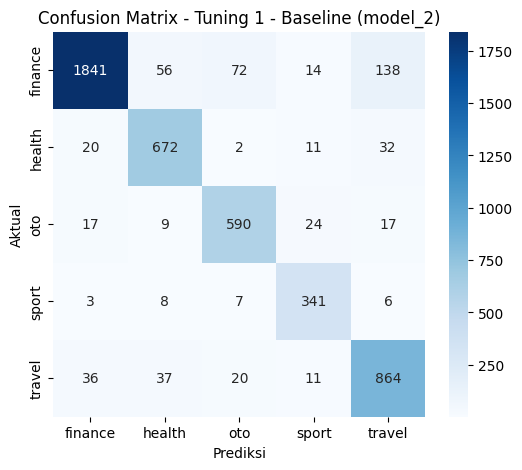

=== Tuning 2 - Num Filters 128 (model_2b) ===
              precision    recall  f1-score   support

     finance     0.9639    0.8807    0.9204      2121
      health     0.8830    0.9009    0.8919       737
         oto     0.8754    0.8980    0.8866       657
       sport     0.8615    0.9370    0.8976       365
      travel     0.8114    0.9112    0.8584       968

    accuracy                         0.8965      4848
   macro avg     0.8790    0.9056    0.8910      4848
weighted avg     0.9014    0.8965    0.8974      4848



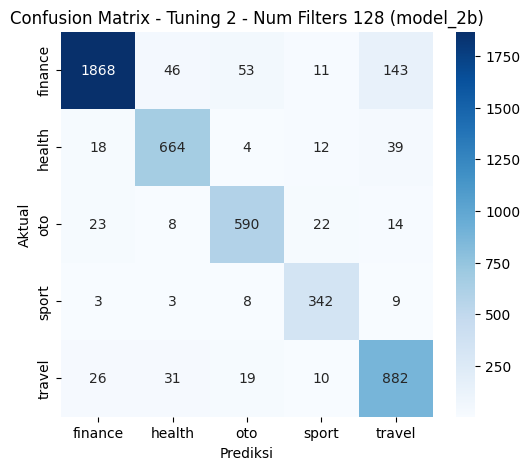

=== Tuning 3 - Dropout 0.3 (model_2c) ===
              precision    recall  f1-score   support

     finance     0.9537    0.8930    0.9223      2121
      health     0.8813    0.9064    0.8936       737
         oto     0.8716    0.8782    0.8749       657
       sport     0.8350    0.9425    0.8855       365
      travel     0.8417    0.8957    0.8679       968

    accuracy                         0.8973      4848
   macro avg     0.8766    0.9031    0.8888      4848
weighted avg     0.9003    0.8973    0.8979      4848



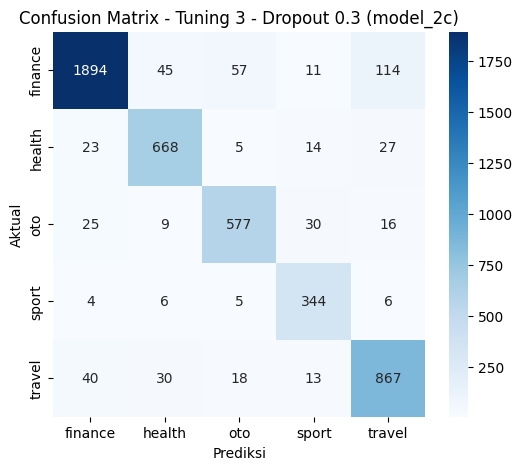

In [39]:
# label kategori asli sesuai urutan alfabetis dari LabelEncoder
label_names = label_encoder.classes_

def evaluasi_model_2(model, X_eval, y_eval_cat, nama_run):
    # prediksi kelas diambil dari index probabilitas softmax tertinggi
    y_pred = np.argmax(model.predict(X_eval, verbose=0), axis=1)
    y_true = np.argmax(y_eval_cat, axis=1)

    print(f'=== {nama_run} ===')
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

    # confusion matrix memakai label kategori asli, bukan angka, supaya mudah dibaca
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix - {nama_run}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

    f1_macro = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    return f1_macro, acc

# evaluasi ketiga tuning di validation set
f1_2, acc_2 = evaluasi_model_2(model_2, X_val_pad, y_val_cat, 'Tuning 1 - Baseline (model_2)')
f1_2b, acc_2b = evaluasi_model_2(model_2b, X_val_pad, y_val_cat, 'Tuning 2 - Num Filters 128 (model_2b)')
f1_2c, acc_2c = evaluasi_model_2(model_2c, X_val_pad, y_val_cat, 'Tuning 3 - Dropout 0.3 (model_2c)')

#### 11.2 Evaluasi Ketiga Eksperimen di Validation Set

In [40]:
# tabel ringkasan F1 macro dan accuracy ketiga tuning di validation set
# jadi acuan utama pemilihan tuning terbaik, bukan cuma val_loss saat training
ringkasan_tuning = pd.DataFrame({
    'Tuning': ['Tuning 1 - Baseline', 'Tuning 2 - Num Filters 128', 'Tuning 3 - Dropout 0.3'],
    'F1 Macro': [round(f1_2, 4), round(f1_2b, 4), round(f1_2c, 4)],
    'Accuracy': [round(acc_2, 4), round(acc_2b, 4), round(acc_2c, 4)],
})
print(ringkasan_tuning)

                       Tuning  F1 Macro  Accuracy
0         Tuning 1 - Baseline    0.8831    0.8886
1  Tuning 2 - Num Filters 128    0.8910    0.8965
2      Tuning 3 - Dropout 0.3    0.8888    0.8973


**✦ Insight dari Model Evaluation ANN Improvement (Validation Set)**

- Ketiga tuning menunjukkan hasil yang saling silang antara F1 macro dan accuracy, tidak ada satu tuning yang unggul mutlak di kedua metrik sekaligus. Tuning 2 (num_filters 128) punya F1 macro tertinggi (0.8910), sementara Tuning 3 (dropout 0.3) punya accuracy tertinggi (0.8973). Tuning 1 (baseline) berada di posisi terakhir untuk kedua metrik (F1 macro 0.8831, accuracy 0.8886).
- Perbedaan arah ini masuk akal kalau dilihat dari komposisi kelasnya. Accuracy lebih dipengaruhi kelas mayoritas seperti finance yang mendominasi 2121 dari 4848 data validasi, sementara F1 macro memberi bobot yang sama ke semua kelas termasuk sport yang cuma punya 365 data. Tuning 3 punya recall finance yang lebih baik (0.8930) dibanding Tuning 2 (0.8807), yang mendorong accuracy keseluruhan naik, tapi Tuning 2 lebih unggul di recall oto (0.8980 lawan 0.8782) dan f1-score yang lebih rata di semua kelas, yang lebih menguntungkan buat F1 macro.
- Recall sport tetap tinggi di ketiga tuning (0.9342, 0.9370, 0.9425), menunjukkan strategi class_weight masih efektif menjaga performa kelas dengan data paling sedikit meski parameter arsitekturnya diubah ubah.
- Precision travel jadi titik lemah paling konsisten di ketiga tuning (0.8174, 0.8114, 0.8417), jauh di bawah precision finance yang di atas 0.95. Artinya model masih sering salah memprediksi kelas lain sebagai travel, bukan sebaliknya.
> **Tuning 2 (model_2b, num_filters 128)** dipilih sebagai representasi terbaik model_2 untuk dievaluasi lebih lanjut di test set karena memiliki f1 macro tertinggi meskipun accuracy-nya sedikit di bawah Tuning 3.

#### 11.3 Evaluasi Final di Test Set (ANN Improvement)

              precision    recall  f1-score   support

     finance     0.9599    0.8695    0.9125      2122
      health     0.8676    0.9159    0.8911       737
         oto     0.8614    0.8720    0.8667       656
       sport     0.8408    0.9260    0.8814       365
      travel     0.8096    0.9050    0.8546       968

    accuracy                         0.8882      4848
   macro avg     0.8679    0.8977    0.8812      4848
weighted avg     0.8936    0.8882    0.8891      4848



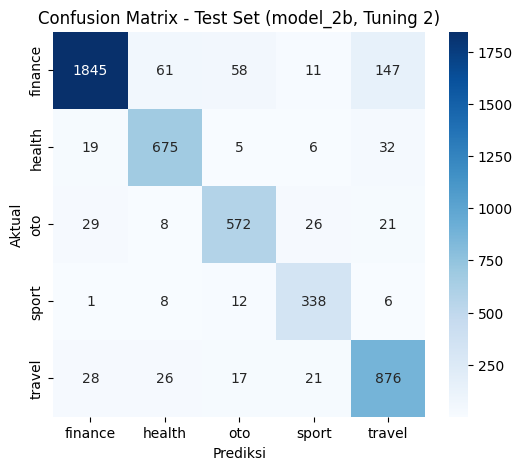

F1 Macro test set: 0.8812
Accuracy test set: 0.8882


In [41]:
# evaluasi Tuning 2 (model_2) di test set, data yang belum pernah disentuh sepanjang proses
y_pred_test = np.argmax(model_2b.predict(X_test_pad, verbose=0), axis=1)
y_true_test = np.argmax(y_test_cat, axis=1)

print(classification_report(y_true_test, y_pred_test, target_names=label_names, digits=4))

cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - Test Set (model_2b, Tuning 2)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

f1_macro_test = f1_score(y_true_test, y_pred_test, average='macro')
acc_test = accuracy_score(y_true_test, y_pred_test)
print('F1 Macro test set:', round(f1_macro_test, 4))
print('Accuracy test set:', round(acc_test, 4))

**✦ Insight dari Evaluasi Final ANN Improvement di Test Set**

- F1 macro turun dari 0.8910 di validation set (Tuning 2) menjadi 0.8812 di test set, selisih 0.0098. Accuracy juga turun dari 0.8965 menjadi 0.8882, selisih 0.0083. Penurunan ini masih dalam rentang wajar dan konsisten dengan pola yang terlihat di ANN Training, jadi tidak ada indikasi model overfit secara ekstrem ke validation set.
- Oto mengalami penurunan F1 paling besar dari seluruh kategori, dari 0.8866 di validation menjadi 0.8667 di test set (turun 0.0199), diikuti sport yang turun dari 0.8976 ke 0.8814 (turun 0.0162). Finance turun dari 0.9204 ke 0.9125, sementara health dan travel relatif stabil, masing masing cuma turun tipis 0.0008 dan 0.0038.
- Travel tetap jadi kelas dengan precision terendah secara konsisten, 0.8096 di test set, artinya model masih sering salah menandai kelas lain sebagai travel meski recall travel-nya sendiri cukup tinggi (0.9050).
- Dibandingkan dengan benchmark ANN Training di test set yang sama (F1 macro 0.8896, accuracy 0.8981), ANN Improvement dengan arsitektur TextCNN ini masih sedikit berada di bawahnya, F1 macro lebih rendah 0.0084 dan accuracy lebih rendah 0.0099. Artinya sampai tahap tuning ini, penggantian arsitektur dari dense network ke TextCNN belum berhasil mengalahkan model ANN Training awal, meski secara desain TextCNN seharusnya lebih mampu menangkap pola bigram dan trigram yang jadi ciri khas temuan EDA sebelumnya.
- Hasil F1 Macro dari ANN Improvement akan dilanjutkan training dengan metode ensemble averaging dan transfer learning untuk meningkatkan nilai F1 Macronya.

#### 11.4 Ensemble Averaging untuk ketiga tuning dari model_2

In [42]:
# ensemble averaging dari ketiga tuning ANN Improvement (model_2, model_2b, model_2c)
proba_val_1 = model_2.predict(X_val_pad, verbose=0)
proba_val_2 = model_2b.predict(X_val_pad, verbose=0)
proba_val_3 = model_2c.predict(X_val_pad, verbose=0)

proba_val_ensemble = (proba_val_1 + proba_val_2 + proba_val_3) / 3
y_pred_val_ensemble = np.argmax(proba_val_ensemble, axis=1)
y_true_val = np.argmax(y_val_cat, axis=1)

print('=== Classification Report - Ensemble Averaging (Validation Set) ===')
print(classification_report(y_true_val, y_pred_val_ensemble, target_names=label_names, digits=4))

f1_macro_ensemble_val = f1_score(y_true_val, y_pred_val_ensemble, average='macro')
acc_ensemble_val = accuracy_score(y_true_val, y_pred_val_ensemble)
print('F1 Macro ensemble (validation):', round(f1_macro_ensemble_val, 4))
print('Accuracy ensemble (validation):', round(acc_ensemble_val, 4))

=== Classification Report - Ensemble Averaging (Validation Set) ===
              precision    recall  f1-score   support

     finance     0.9635    0.8840    0.9221      2121
      health     0.8799    0.9145    0.8969       737
         oto     0.8717    0.8995    0.8854       657
       sport     0.8693    0.9479    0.9069       365
      travel     0.8292    0.9081    0.8669       968

    accuracy                         0.9004      4848
   macro avg     0.8827    0.9108    0.8956      4848
weighted avg     0.9045    0.9004    0.9011      4848

F1 Macro ensemble (validation): 0.8956
Accuracy ensemble (validation): 0.9004


In [43]:
proba_test_1 = model_2.predict(X_test_pad, verbose=0)
proba_test_2 = model_2b.predict(X_test_pad, verbose=0)
proba_test_3 = model_2c.predict(X_test_pad, verbose=0)

proba_test_ensemble = (proba_test_1 + proba_test_2 + proba_test_3) / 3
y_pred_test_ensemble = np.argmax(proba_test_ensemble, axis=1)
y_true_test = np.argmax(y_test_cat, axis=1)

print('=== Classification Report - Ensemble Averaging (Test Set) ===')
print(classification_report(y_true_test, y_pred_test_ensemble, target_names=label_names, digits=4))

f1_macro_ensemble_test = f1_score(y_true_test, y_pred_test_ensemble, average='macro')
acc_ensemble_test = accuracy_score(y_true_test, y_pred_test_ensemble)
print('F1 Macro ensemble (test):', round(f1_macro_ensemble_test, 4))
print('Accuracy ensemble (test):', round(acc_ensemble_test, 4))

=== Classification Report - Ensemble Averaging (Test Set) ===
              precision    recall  f1-score   support

     finance     0.9619    0.8808    0.9196      2122
      health     0.8626    0.9199    0.8903       737
         oto     0.8824    0.8689    0.8756       656
       sport     0.8501    0.9479    0.8964       365
      travel     0.8236    0.9070    0.8633       968

    accuracy                         0.8954      4848
   macro avg     0.8761    0.9049    0.8890      4848
weighted avg     0.9000    0.8954    0.8962      4848

F1 Macro ensemble (test): 0.889
Accuracy ensemble (test): 0.8954


**✦ Insight dari Ensemble Averaging**

* Setelah dilakukan training dan test dengan menggunakan Ensemble Averaging terlihat bahwa Nilai F1 Macro masih rendah dari F1 Macro di ANN Training yaitu hanya di angka 0.8890 (selisih 0.0006) dengan accuracy di 0.8954 (selisih 0.0027), untuk itu dilanjutkan dengan metode Transfer Learning dengan membuat model satu lagi yaitu model_3().

#### 11.5 Transfer Learning dengan Word2Vec

In [44]:
# tokenisasi sederhana berbasis spasi, karena title_clean sudah bersih dari tanda baca
train_tokens = [text.split() for text in X_train]

EMBED_DIM = 64  # disamakan dengan embedding_dim di model_1 dan model_2 supaya perbandingan tetap adil

w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=EMBED_DIM,
    window=5,
    min_count=1,
    workers=1,
    seed=88,
    sg=1  # skip-gram, biasanya lebih unggul dibanding CBOW untuk corpus yang relatif kecil
)

print('Jumlah kata unik di vocabulary Word2Vec:', len(w2v_model.wv))

Jumlah kata unik di vocabulary Word2Vec: 14661


In [45]:
# Menyusun embedding matrix, disesuaikan dengan index kata dari tokenizer yang sudah ada
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
oov_count = 0

for word, idx in tokenizer.word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]
    else:
        oov_count += 1

print('Jumlah kata di tokenizer yang tidak punya vector Word2Vec:', oov_count)
print('Total kata di tokenizer (dibatasi vocab_size):', min(len(tokenizer.word_index), VOCAB_SIZE))

Jumlah kata di tokenizer yang tidak punya vector Word2Vec: 1
Total kata di tokenizer (dibatasi vocab_size): 10000


In [46]:
# Membut model ke 3 (model_3) dengan arsitektur dari Tuning 2 (num_filters=128)
def build_model_3(vocab_size=VOCAB_SIZE, max_length=MAX_LENGTH, embed_dim=EMBED_DIM,
                   embedding_matrix=embedding_matrix, filter_sizes=(2, 3, 4),
                   num_filters=128, dense_units=64, dropout_rate=0.5, seed=88):
    tf.random.set_seed(seed)

    input_layer = Input(shape=(max_length,), name='input_title')

    # bedanya di sini, embedding diinisialisasi dari Word2Vec, bukan random,
    # trainable=True supaya representasi tetap bisa disesuaikan lebih lanjut ke tugas klasifikasi
    embedding_layer = Embedding(
        input_dim=vocab_size, output_dim=embed_dim,
        weights=[embedding_matrix], trainable=True, name='embedding_pretrained'
    )(input_layer)

    embedding_layer = SpatialDropout1D(0.2, name='spatial_dropout')(embedding_layer)

    conv_branches = []
    for k in filter_sizes:
        conv = Conv1D(filters=num_filters, kernel_size=k, activation='relu', name=f'conv1d_k{k}')(embedding_layer)
        pool = GlobalMaxPooling1D(name=f'global_max_pool_k{k}')(conv)
        conv_branches.append(pool)

    concatenated = Concatenate(name='concat_ngram_features')(conv_branches)
    dense_layer = Dense(dense_units, activation='relu', name='dense_combine')(concatenated)
    dense_layer = Dropout(dropout_rate, name='dropout')(dense_layer)
    output_layer = Dense(5, activation='softmax', name='output')(dense_layer)

    model = Model(inputs=input_layer, outputs=output_layer, name='model_3_pretrained_textcnn')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model_3 = build_model_3()
model_3.summary()

Model: "model_3_pretrained_textcnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_title         │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_pretrain… │ (None, 15, 64)    │    640,000 │ input_title[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 15, 64)    │          0 │ embedding_pretra… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k2 (Conv1D)  │ (None, 14, 128)   │     16,512 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k3 (Conv1D)  │ (None, 13, 128)   │     24,704 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_k4 (Conv1D)  │ (None, 12, 128)   │     32,896 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k2  │ (None, 128)       │          0 │ conv1d_k2[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k3  │ (None, 128)       │          0 │ conv1d_k3[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool_k4  │ (None, 128)       │          0 │ conv1d_k4[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_ngram_featu… │ (None, 384)       │          0 │ global_max_pool_… │
│ (Concatenate)       │                   │            │ global_max_pool_… │
│                     │                   │            │ global_max_pool_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_combine       │ (None, 64)        │     24,640 │ concat_ngram_fea… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_combine[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 739,077 (2.82 MB)

 Trainable params: 739,077 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Training kembali dengan konfigurasi disamakan dengan tuning ANN Improvement sebelumnya supaya perbandingan berimbang
early_stop_3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_3 = model_3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop_3],
    verbose=1
)

Epoch 1/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6074 - loss: 1.1016 - val_accuracy: 0.8311 - val_loss: 0.5156
Epoch 2/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8329 - loss: 0.4969 - val_accuracy: 0.8738 - val_loss: 0.3768
Epoch 3/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8912 - loss: 0.3091 - val_accuracy: 0.8954 - val_loss: 0.3234
Epoch 4/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9246 - loss: 0.2084 - val_accuracy: 0.9008 - val_loss: 0.3071
Epoch 5/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9434 - loss: 0.1563 - val_accuracy: 0.8913 - val_loss: 0.3813
Epoch 6/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9507 - loss: 0.1241 - val_accuracy: 0.8998 - val_loss: 0.3742
Epoch 7/30
707/707 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9630 - loss: 0.0913 - val_accuracy: 0.9022 - val_loss: 0.3860


In [48]:
# Melakukan Evaluasi Train di validation set
y_pred_val_3 = np.argmax(model_3.predict(X_val_pad, verbose=0), axis=1)

print('=== Classification Report - model_3 (Transfer Learning Word2Vec) - Validation Set ===')
print(classification_report(y_true_val, y_pred_val_3, target_names=label_names, digits=4))

f1_macro_val_3 = f1_score(y_true_val, y_pred_val_3, average='macro')
acc_val_3 = accuracy_score(y_true_val, y_pred_val_3)
print('F1 Macro model_3 (validation):', round(f1_macro_val_3, 4))
print('Accuracy model_3 (validation):', round(acc_val_3, 4))

=== Classification Report - model_3 (Transfer Learning Word2Vec) - Validation Set ===
              precision    recall  f1-score   support

     finance     0.9540    0.8996    0.9260      2121
      health     0.8758    0.9186    0.8967       737
         oto     0.8723    0.8737    0.8730       657
       sport     0.8402    0.9507    0.8920       365
      travel     0.8576    0.8895    0.8732       968

    accuracy                         0.9008      4848
   macro avg     0.8800    0.9064    0.8922      4848
weighted avg     0.9032    0.9008    0.9013      4848

F1 Macro model_3 (validation): 0.8922
Accuracy model_3 (validation): 0.9008


In [49]:
# Melakukan Evaluasi Test set
y_pred_test_3 = np.argmax(model_3.predict(X_test_pad, verbose=0), axis=1)

print('=== Classification Report - model_3 (Transfer Learning Word2Vec) - Test Set ===')
print(classification_report(y_true_test, y_pred_test_3, target_names=label_names, digits=4))

f1_macro_test_3 = f1_score(y_true_test, y_pred_test_3, average='macro')
acc_test_3 = accuracy_score(y_true_test, y_pred_test_3)
print('F1 Macro model_3 (test):', round(f1_macro_test_3, 4))
print('Accuracy model_3 (test):', round(acc_test_3, 4))

=== Classification Report - model_3 (Transfer Learning Word2Vec) - Test Set ===
              precision    recall  f1-score   support

     finance     0.9559    0.8893    0.9214      2122
      health     0.8430    0.9254    0.8823       737
         oto     0.8709    0.8537    0.8622       656
       sport     0.8571    0.9534    0.9027       365
      travel     0.8455    0.8874    0.8659       968

    accuracy                         0.8944      4848
   macro avg     0.8745    0.9018    0.8869      4848
weighted avg     0.8978    0.8944    0.8950      4848

F1 Macro model_3 (test): 0.8869
Accuracy model_3 (test): 0.8944


=== Classification Report - Ensemble 4 Model (model_2, model_2b, model_2c, model_3) - Validation ===
              precision    recall  f1-score   support

     finance     0.9614    0.8920    0.9254      2121
      health     0.8810    0.9145    0.8975       737
         oto     0.8782    0.8995    0.8887       657
       sport     0.8801    0.9452    0.9115       365
      travel     0.8343    0.9050    0.8682       968

    accuracy                         0.9031      4848
   macro avg     0.8870    0.9113    0.8983      4848
weighted avg     0.9064    0.9031    0.9037      4848

F1 Macro ensemble4 (validation): 0.8983
Accuracy ensemble4 (validation): 0.9031
=== Classification Report - Ensemble 4 Model - Test Set ===
              precision    recall  f1-score   support

     finance     0.9621    0.8855    0.9222      2122
      health     0.8616    0.9294    0.8943       737
         oto     0.8814    0.8720    0.8766       656
       sport     0.8628    0.9479    0.9034       365

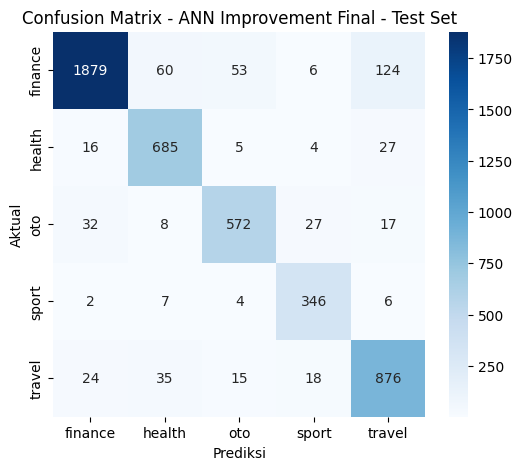

F1 Macro ensemble4 (test): 0.8929
Accuracy ensemble4 (test): 0.8989


In [50]:
# Lakukan Ensemble Averaging kembali dengan menambahkan hasil dari model_3()
proba_val_4 = model_3.predict(X_val_pad, verbose=0)
proba_val_ensemble4 = (proba_val_1 + proba_val_2 + proba_val_3 + proba_val_4) / 4
y_pred_val_ensemble4 = np.argmax(proba_val_ensemble4, axis=1)

print('=== Classification Report - Ensemble 4 Model (model_2, model_2b, model_2c, model_3) - Validation ===')
print(classification_report(y_true_val, y_pred_val_ensemble4, target_names=label_names, digits=4))
f1_macro_ens4_val = f1_score(y_true_val, y_pred_val_ensemble4, average='macro')
acc_ens4_val = accuracy_score(y_true_val, y_pred_val_ensemble4)
print('F1 Macro ensemble4 (validation):', round(f1_macro_ens4_val, 4))
print('Accuracy ensemble4 (validation):', round(acc_ens4_val, 4))

proba_test_4 = model_3.predict(X_test_pad, verbose=0)
proba_test_ensemble4 = (proba_test_1 + proba_test_2 + proba_test_3 + proba_test_4) / 4
y_pred_test_ensemble4 = np.argmax(proba_test_ensemble4, axis=1)

print('=== Classification Report - Ensemble 4 Model - Test Set ===')
print(classification_report(y_true_test, y_pred_test_ensemble4, target_names=label_names, digits=4))

cm_test = confusion_matrix(y_true_test, y_pred_test_ensemble4)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix - ANN Improvement Final - Test Set')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

f1_macro_ens4_test = f1_score(y_true_test, y_pred_test_ensemble4, average='macro')
acc_ens4_test = accuracy_score(y_true_test, y_pred_test_ensemble4)
print('F1 Macro ensemble4 (test):', round(f1_macro_ens4_test, 4))
print('Accuracy ensemble4 (test):', round(acc_ens4_test, 4))

**✦ Insight dari Keputusan Final Model ANN Improvement**

- Ensemble tiga tuning TextCNN saja (model_2, model_2b, model_2c) menghasilkan F1 macro test set 0.8890, masih tipis di bawah benchmark ANN Training sebesar 0.8896. Transfer learning sendirian (model_3) malah lebih rendah lagi, F1 macro 0.8869, karena satu model dengan satu sumber representasi embedding tetap punya batas kemampuan menangkap seluruh variasi pola di data.
- Begitu model_3 dimasukkan sebagai anggota keempat ensemble, hasilnya naik jadi F1 macro test set 0.8929 dan accuracy 0.8989, melewati ANN Training di kedua metrik sekaligus (F1 macro naik 0.0033, accuracy naik 0.0008). Lift ini masuk akal karena model_3 punya sumber representasi kata yang berbeda dari tiga model lainnya, embedding-nya sudah punya bekal hubungan antar kata dari Word2Vec, bukan dilatih dari nol seperti mdari ketiga model_2. Perbedaan sumber ini yang membuat pola kesalahan model_3 cukup berbeda dari yang lain, sehingga saat probabilitasnya dirata-rata bersama, kesalahan yang tumpang tindih di satu model bisa dikompensasi oleh tiga model lainnya.
- Kalau dilihat per kategori, travel tetap jadi kelas paling menantang (F1 0.8682), tapi ini sudah membaik dibanding ensemble tiga model saja (F1 0.8633). Finance tetap paling stabil (F1 0.9222) karena didukung data yang jauh lebih banyak.
- Karena seluruh anggota ensemble berasal dari arsitektur ANN Improvement (TextCNN dengan variasi hyperparameter, dan TextCNN dengan pretrained embedding), keputusan ini tetap memenuhi ketentuan bahwa model terbaik yang dipakai di tahap inference dan deployment harus berasal dari ANN Improvement, bukan ANN Training.
- Model final yang dipakai untuk tahap selanjutnya adalah ensemble soft-voting dari model_2, model_2b, model_2c, dan model_3, dengan skema rata-rata probabilitas berbobot sama.

### **12. Model Saving**

Setelah mendapat Model terbaik dari ANN Improvement selanjutnya Model tersebut disimpan untuk kemudian digunakan sebagai prediksi di Model Inference.

In [51]:
# membuat folder khusus untuk menyimpan seluruh artefak model final
os.makedirs('saved_model', exist_ok=True)

# simpan keempat model yang jadi anggota ensemble final
model_2.save('saved_model/model_2_baseline.keras')
model_2b.save('saved_model/model_2b_numfilters128.keras')
model_2c.save('saved_model/model_2c_dropout03.keras')
model_3.save('saved_model/model_3_word2vec.keras')

# simpan tokenizer, dipakai lagi nanti untuk mengubah teks baru jadi angka
with open('saved_model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# simpan label encoder, dipakai lagi untuk mengubah hasil prediksi angka balik jadi nama kategori
with open('saved_model/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print('✅ Seluruh artefak model final (ensemble 4 model) berhasil disimpan di folder saved_model')

✅ Seluruh artefak model final (ensemble 4 model) berhasil disimpan di folder saved_model


### **13. Model Inference**
Pada tahap ini pengujian dilakukan pada file yang berbeda yaitu di file [`P2G7_Muhammad_Akbar_Suharbi_inference.ipynb`](P2G7_Muhammad_Akbar_Suharbi_inference.ipynb)

> Prediksi telah berhasil dilakukan dan berikut adalah Interprestasi dari hasil prediksi dari Model Inference.

**✦ Insight dari Model Inference**

- Kelima judul uji berhasil diklasifikasikan ke kategori yang sesuai, yaitu **finance, health, oto, sport,** dan **travel**, tanpa adanya kesalahan prediksi. Hasil ini menunjukkan bahwa model ensemble ANN mampu melakukan klasifikasi dengan baik pada data baru yang memiliki topik jelas dan representatif.

- Berdasarkan nilai **confidence**, kategori **travel** memperoleh nilai tertinggi sebesar **0.999978**, diikuti oleh **sport** (**0.999656**) dan **oto** (**0.999466**). Tingginya confidence pada ketiga kategori tersebut mengindikasikan bahwa model sangat yakin terhadap hasil prediksinya. Hal ini kemungkinan disebabkan oleh penggunaan kosakata yang khas dan spesifik pada masing-masing kategori, seperti *mobil listrik*, *timnas Indonesia*, *kualifikasi Piala Dunia*, dan *destinasi wisata*, sehingga relatif mudah dibedakan dari kategori lainnya.

- Kategori **health** memiliki nilai confidence paling rendah di antara kelima sampel, yaitu **0.994534**, meskipun nilainya masih tergolong sangat tinggi. Distribusi probabilitas menunjukkan bahwa probabilitas terbesar kedua berada pada kategori **finance** sebesar **0.004037**, sedangkan probabilitas terhadap kategori lainnya berada di bawah **0.001**. Hal ini menunjukkan bahwa model tetap memiliki keyakinan yang sangat kuat terhadap prediksi utamanya, sehingga probabilitas pada kategori lain belum memberikan pengaruh yang signifikan terhadap hasil klasifikasi.

- Meskipun kategori **finance** memiliki confidence sedikit lebih tinggi, yaitu **0.994644**, distribusi probabilitasnya menunjukkan probabilitas terbesar kedua pada kategori **travel** sebesar **0.004511**. Pola ini sejalan dengan hasil evaluasi pada tahap training dan test sebelumnya, di mana kategori **finance** dan **travel** merupakan pasangan kategori yang paling sering mengalami kesalahan (tertukar kategori). Dengan demikian, kecenderungan tersebut masih terlihat pada tahap inference, meskipun hanya dalam bentuk probabilitas sekunder yang sangat kecil dan tidak memengaruhi keputusan akhir model.

- Seluruh data uji memiliki nilai **Perlu_Review_Manual = False**, yang menunjukkan bahwa semua prediksi berada di atas ambang batas confidence yang telah ditetapkan (60%). Dengan demikian, tidak ada hasil klasifikasi yang memerlukan proses verifikasi atau peninjauan ulang secara manual.

- Secara keseluruhan, hasil inference menunjukkan bahwa model ensemble ANN memiliki kemampuan generalisasi yang baik terhadap data baru. Selain berhasil mengklasifikasikan seluruh sampel dengan benar, model juga mempertahankan nilai confidence yang sangat tinggi pada setiap prediksi. Meskipun masih terlihat sedikit kecenderungan *confusion* antara kategori **finance** dan **travel**, namun nilai tersebut cenderung kecil sehingga tidak memengaruhi hasil klasifikasi akhir. Hal ini menunjukkan bahwa model telah cukup andal untuk diterapkan pada proses klasifikasi otomatis kategori berita Indonesia.

### **14. Kesimpulan Menyeluruh**

#### 14.1 Pencapaian terhadap Objektif Project

Merujuk kembali ke tiga objektif yang ditulis di bagian Perkenalan:

- **Objektif 1, membangun model ANN untuk klasifikasi judul berita ke 5 kategori.** Tercapai. Model final berhasil mengklasifikasikan judul ke kategori finance, health, oto, sport, dan travel dengan accuracy 0.8989 dan F1 macro 0.8929 di test set, data yang sama sekali belum pernah dilihat model sepanjang proses training maupun tuning.
- **Objektif 2, membandingkan arsitektur ANN dasar dengan arsitektur yang lebih baik.** Tercapai. ANN Training memakai Dense Network sederhana sebagai baseline, sementara ANN Improvement mengeksplorasi TextCNN dengan tiga variasi hyperparameter, ensemble averaging, dan transfer learning lewat pretrained embedding Word2Vec.
- **Objektif 3, menghasilkan model yang bisa dipakai untuk simulasi input judul baru.** Tercapai sebagian di tahap ini. Model Inference sudah dijalankan di notebook terpisah dan terbukti bisa memprediksi judul baru dengan confidence tinggi, lengkap dengan mekanisme flag Perlu_Review_Manual untuk kasus yang confidence-nya rendah. Simulasi deployment sesungguhnya (webapps) akan dilanjutkan di tahap berikutnya.

#### 14.2 Insight Kunci dari EDA yang Membentuk Keputusan Modeling

- Pemilihan 5 kategori (finance, health, oto, sport, travel) di awal terbukti tepat. Word frequency dan n-gram analysis menunjukkan tiap kategori punya vocabulary khas sendiri, finance dengan istilah ekonomi dan nama pejabat, oto dengan merek kendaraan, sport dengan nama atlet dan kompetisi, meski satu kata yaitu "corona" mendominasi hampir semua kategori karena rentang data bertepatan dengan awal pandemi di Indonesia.
- Class imbalance dengan rasio 5.8 kali antara finance dan sport terbukti berdampak nyata ke training. Tanpa class_weight, kelas minoritas seperti sport berisiko punya recall rendah. Setelah class_weight diterapkan, recall sport justru konsisten jadi salah satu yang tertinggi di semua eksperimen, baik ANN Training maupun ANN Improvement, jadi strategi ini terbukti efektif.
- Distribusi panjang judul yang mendekati normal (rata-rata 8 sampai 10 kata, skewness dan kurtosis mendekati nol) memberi dasar kuat untuk penentuan MAX_LENGTH di tahap padding, tidak perlu antisipasi outlier ekstrem.
- Temuan bigram dan trigram menjadi alasan langsung kenapa arsitektur ANN Improvement diarahkan ke TextCNN, karena konteks frasa terbukti jauh lebih informatif dibanding kata tunggal, terutama untuk memisahkan judul yang sama sama mengandung kata "corona" tapi beda kategori.

#### 14.3 Perbandingan ANN Training vs ANN Improvement

| Tahap | Model Representatif | F1 Macro (Test) | Accuracy (Test) |
|---|---|---:|---:|
| ANN Training | model_1c (Dense Network, Tuning 3) | 0.8896 | 0.8981 |
| ANN Improvement | Ensemble 4 model (TextCNN x3 + Word2Vec TextCNN) | 0.8929 | 0.8989 |
| **Selisih** | | **+0.0033** | **+0.0008** |

Beberapa hal yang menjadi catatan dalam meningkatkan hasil ANN Improvement agar lebih baik dari ANN Training:

- TextCNN sendirian, sebelum di-ensemble, justru belum berhasil mengalahkan benchmark. Tuning terbaik TextCNN tunggal (model_2b) mencatat F1 macro 0.8812 di test set, masih di bawah 0.8896 milik ANN Training. Artinya penggantian arsitektur dari Dense Network ke TextCNN saja tidak otomatis memberi keunggulan, meski secara desain TextCNN seharusnya lebih baik menangkap pola n-gram.
- Ensemble tiga tuning TextCNN (model_2, model_2b, model_2c) juga masih tipis di bawah benchmark, F1 macro 0.8890 di test set. Baru setelah model_3 hasil transfer learning Word2Vec ditambahkan sebagai anggota keempat ensemble, F1 macro naik jadi 0.8929, melewati ANN Training.
- Ini berarti kemenangan ANN Improvement bukan datang dari satu arsitektur tunggal yang jauh lebih pintar, melainkan dari kombinasi empat model dengan sumber representasi kata yang berbeda beda, tiga di antaranya belajar embedding dari nol dan satu belajar dari Word2Vec. Perbedaan sumber ini membuat pola kesalahan tiap model sedikit berbeda, sehingga saat probabilitasnya dirata rata, kesalahan yang tumpang tindih di satu model bisa dikompensasi oleh model lain.
- Margin akhir yang tipis (F1 macro naik 0.0033) masuk akal kalau dikaitkan lagi dengan temuan EDA di atas, karena lima kategori ini memang sengaja dipilih karena vocabulary-nya sudah cukup terpisah sejak awal, model Dense Network sederhana pun sebenarnya sudah bisa menangkap sebagian besar sinyal klasifikasi hanya dari kemunculan kata. TextCNN unggul di menangkap urutan dan konteks frasa, tapi keunggulan ini baru signifikan kalau datanya butuh pemahaman konteks yang lebih dalam, bukan sekadar kata kunci yang sudah cukup khas per kategori.

#### 14.4 Kelebihan dan Keterbatasan Model

**Kelebihan**
- Pipeline sudah reproducible penuh berkat konfigurasi seed dan determinism yang konsisten di cell pertama, hasil training tidak berubah ubah setiap kali notebook dijalankan ulang dari kernel bersih.
- Class imbalance ditangani secara eksplisit lewat class_weight, terbukti efektif menjaga recall kategori minoritas seperti sport tetap tinggi di semua eksperimen.
- Model final sudah dilengkapi mekanisme confidence threshold di tahap inference, sehingga prediksi dengan keyakinan rendah bisa otomatis ditandai untuk ditinjau manual oleh editor, bukan diterima mentah mentah.
- Proses pemilihan model tidak asal ambil yang paling tinggi angkanya, tapi melalui tahapan bertingkat, evaluasi validation set, evaluasi test set, ensemble averaging, sampai transfer learning, dengan alasan di setiap langkah.

**Keterbatasan**
- Kesalahan klasifikasi antara finance, travel, dan oto tetap muncul konsisten di semua model, dari ANN Training sampai ANN Improvement. Ini kemungkinan besar batas alami dari bahasa itu sendiri, judul finance yang membahas sektor pariwisata atau industri otomotif memang wajar memakai kosakata yang tumpang tindih, bukan sesuatu yang bisa diperbaiki hanya dengan mengganti arsitektur.
- Word2Vec di tahap transfer learning dilatih dari corpus training project ini sendiri, yang seluruhnya berasal dari periode Januari sampai Juni 2020, masa awal pandemi. Representasi kata yang dipelajari kemungkinan besar bias ke kosakata pandemi. Model ini belum tentu setangguh ini kalau dipakai untuk judul dari periode lain yang temanya jauh berbeda.
- Model final berupa ensemble dari 4 model terpisah, bukan satu model tunggal. Ini artinya setiap prediksi butuh 4 kali forward pass, konsekuensinya beban komputasi dan latency saat inference lebih besar dibanding kalau memakai satu model saja, sesuatu yang perlu dipikirkan lagi kalau nanti butuh skala produksi dengan traffic tinggi.
- Model hanya diuji dengan teks judul yang pendek, rata rata 8 sampai 10 kata. Belum ada pengujian apakah model ini juga bekerja baik kalau nanti dipakai untuk teks yang lebih panjang seperti isi artikel penuh.

#### 14.5 Rencana Pengembangan Lanjutan (Feature Improvement)

Beberapa arah pengembangan yang bisa jadi langkah lanjutan project ini, sebagai catatan improvement untuk berikutnya:

- **Perluasan rentang waktu dataset.** Menambah data dari periode di luar masa pandemi supaya representasi kata tidak terlalu didominasi kosakata corona, sehingga model lebih general dan tidak bergantung pada konteks satu peristiwa besar saja.
- **Eksplorasi pretrained embedding yang lebih kaya konteks.** Word2Vec yang dipakai sekarang masih bersifat context-independent, satu kata selalu punya representasi yang sama di mana pun kemunculannya. Model berbasis transformer seperti IndoBERT berpotensi menangkap makna kata yang berubah tergantung konteks kalimat, yang mungkin bisa membantu kasus finance dan travel yang sering tertukar.
- **Penanganan class imbalance dengan pendekatan tambahan.** Selain class_weight, teknik seperti data augmentation berbasis back-translation atau synonym replacement khusus untuk kategori sport yang datanya paling sedikit bisa dicoba untuk menambah variasi contoh tanpa perlu scraping data baru.
- **Model compression untuk kebutuhan produksi.** Mengingat model final berupa ensemble 4 model, langkah lanjutan yang relevan adalah knowledge distillation, melatih satu model kecil untuk meniru output ensemble ini, supaya beban inference lebih ringan tanpa kehilangan banyak performa.
- **Hyperparameter tuning yang lebih sistematis.** Tuning yang dilakukan di project ini masih manual (mencoba beberapa kombinasi satu per satu). Ke depannya, pemakaian tools seperti KerasTuner atau Optuna bisa membantu menemukan kombinasi hyperparameter yang lebih optimal secara lebih terarah.
- **Monitoring performa model dari waktu ke waktu.** Karena kosakata berita bisa berubah seiring waktu, terutama untuk kategori yang sensitif terhadap peristiwa terkini, perlu ada mekanisme monitoring performa model secara berkala setelah deployment, supaya penurunan performa akibat perubahan pola bahasa bisa terdeteksi lebih awal.